This report explores mentor-mentee feedback data from JMentors over the past period from 2024 to today. The analysis aims to identify key insights about the program’s effectiveness, communication dynamics, and participant experiences based on midterm and end of the year survey responses.

We analyze responses from both mentors and mentees across several dimensions including:
- Experience ratings
- Program impact
- Relationship quality
- Willingness to recommend the program

## Dataset Overview

The dataset includes survey responses from mentors and mentees who answered a common set of questions.

Here is a quick summary of the columns:

- On a scale of 1–10, how would you rate your experience as a mentee in this program?
- Would you recommend the program to a colleague or a friend? (1–10)
- How often did y (1–5, 3 being the right amount)ou meet?
- Was meeting as often as you did enough time to help you achieve the mentorship prograt amount)
- Describe your relationship with your mentor/mentee (1–5)
- Did you feel comfortable sharing information and/or experiences with your mentor/mentee? (1–5)
- Was the mentorship program a valuable experience? (1–5)
- On a scale of 1–10, how would you rate the program's impact on your personal, professional, or leadeship skills?
s + No Votes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from functools import reduce

In [3]:
def read_files(path):
    return pd.read_csv(path)
    
matches_24 = pd.read_csv("C:\\Users\\Owner\\OneDrive\\Desktop\\Dan's project\\2024\\24_matches.csv", skiprows=3, header=0)
mid_mentee_24 = read_files("C:\\Users\\Owner\\OneDrive\\Desktop\\Dan's project\\2024\\Midterm Mentee_24.csv")
mid_mentor_24 = read_files("C:\\Users\\Owner\\OneDrive\\Desktop\\Dan's project\\2024\\Midterm Mentor_24.csv")
eop_mentee_24 = read_files("C:\\Users\\Owner\\OneDrive\\Desktop\\Dan's project\\2024\\EOP Mentee_24.csv")
eop_mentor_24 = read_files("C:\\Users\\Owner\\OneDrive\\Desktop\\Dan's project\\2024\\EOP Mentor_24.csv")
matches_25 = read_files("C:\\Users\\Owner\\OneDrive\\Desktop\\Dan's project\\2025\\25_matches.csv")
mid_mentee_25 = read_files("C:\\Users\\Owner\\OneDrive\\Desktop\\Dan's project\\2025\\Midterm Mentee_25.csv")
mid_mentor_25 = read_files("C:\\Users\\Owner\\OneDrive\\Desktop\\Dan's project\\2025\\Midterm Mentor_25.csv")

## Preprocess

#### Matches preprocess

In [16]:
def matches_relevant_cols(matches):
    return matches[['Mentor Name', 'Mentee Name']].iloc[:-1].dropna(how='all')

matches_24 = matches_relevant_cols(matches_24)
matches_25 = matches_relevant_cols(matches_25)

In [20]:
# EOP mentees & mentors- drop unnecessary columns

def eop_mentee(df):
    df.drop(columns = ['Would you be willing to share your mentorship program experience at the wrap up meeting?',
                     'If comfortable, please provide us with some quotes about your experiences in this program. \n\nWe are looking for quotes that we can use in marketing materials to promote the program. '], 
                  inplace=True)
    return df

eop_mentee_24 = eop_mentee(eop_mentee_24)

In [22]:
def eop_mentor(df):
    df.drop(columns = ['Would you be willing to share your mentorship program experience at the wrap up meeting? ',
       'If comfortable, please provide us with some quotes about your experiences in this program. \n\nWe are looking for quotes that we can use in marketing materials to promote the program. '],
                   inplace=True)
    return df

eop_mentor_24 = eop_mentor(eop_mentor_24)

In [24]:
def rename_cols(df):
    df.columns = ['Timestamp', 'Your Name', 
                  'Rate your experience', 
                  'Would you recommend the program?', 
                  'Would you consider serving as a mentor?', 
                  'Were the articles helpful?', 
                  'How often did you meet?', 
                  'Did you meet enough?', 
                  'Describe your relationship',
                  'Comfortable sharing information?',
                  'Valuable experience?', 
                  'Most satisfying thing?', 
                  'Program impact?', 
                  'Impact text', 
                  'Suggestions for improvement']
    df['Most satisfying thing?'].fillna("")
    df['Impact text'].fillna("")
    df['Suggestions for improvement'].fillna("")
    df['Your Name'] = df['Your Name'].str.strip().str.replace('  ', ' ', regex=False).str.replace('\xa0', '', regex=False)
    return df

# Add new surveys to this array 
arr = [mid_mentee_24, mid_mentor_24, eop_mentee_24, eop_mentor_24, mid_mentee_25, mid_mentor_25]
for el in arr:
    el = rename_cols(el)

In [26]:
#specific issues with those surveys. Ensure participants use their full name, and that the name matches with the name on the matches csv

mid_mentee_24['Your Name'] = mid_mentee_24['Your Name'].str.strip().str.replace('  ', ' ', regex=False).str.replace('Leya', 'Leya Aronoff')
matches_24['Mentor Name'] = matches_24['Mentor Name'].str.replace('\xa0', '', regex=False).str.replace('  ', ' ', regex=False).str.replace('Alexa Rubinov', 'Alexandra Rubinov')

### Means to numeric questions

In [64]:
def means(df, label=""):
    means_df = df.mean(numeric_only=True).reset_index()
    means_df.columns = ['questions', label]
    means_df[label] = means_df[label].round(2)
    return means_df

dfs = {'mid_mentee_24': mid_mentee_24, 'mid_mentor_24': mid_mentor_24, 
        'eop_mentee_24': eop_mentee_24, 'eop_mentor_24': eop_mentor_24,
        'mid_mentee_25': mid_mentee_25, 'mid_mentor_25': mid_mentor_25}

means_results = {}

for label, df in dfs.items():
    means_results[label] = means(df, label = label)

dfs = list(means_results.values())
merged_df = reduce(lambda left, right: pd.merge(left, right, on='questions'), dfs)

### Averages deviation mentor mentee

In [67]:
# merged_mid
def scatter_means(df, label='', year=''):
    x_lab = label + '_mentor_' + year
    y_lab = label + '_mentee_' + year
    sns.set(style='whitegrid')
    plt.figure(figsize=(10,6))
    sns.scatterplot(data=df, x = x_lab, y = y_lab, hue='questions', palette='pastel')
    max_score = max(df[[x_lab, y_lab]].max())
    plt.plot([0, max_score], [0, max_score], '--', color = 'gray')
    plt.xlabel('means mentors')
    plt.ylabel('means mentees')
    plt.title('scatter of averages ' + label + year)
    plt.legend(bbox_to_anchor=(1.05,1), loc='center left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()

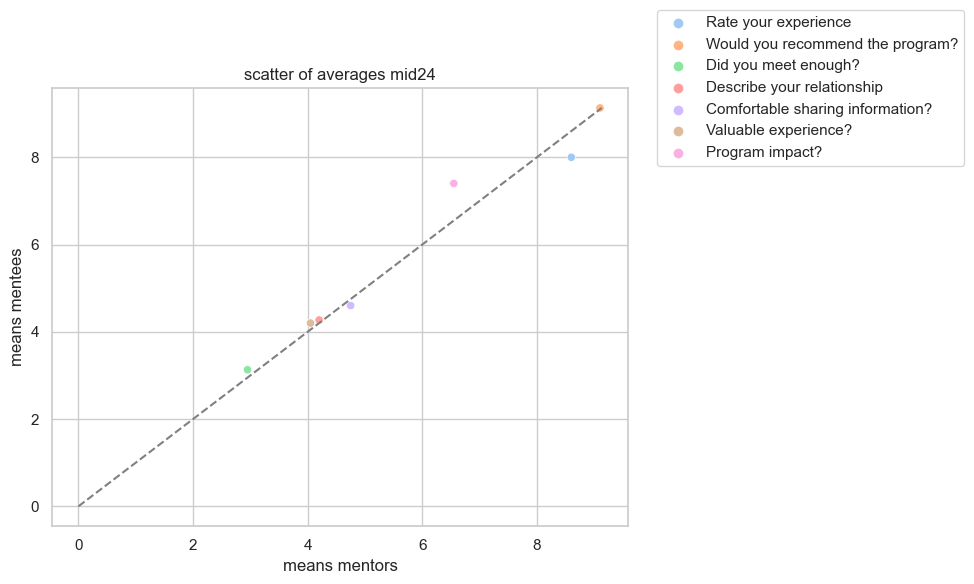

In [69]:
scatter_means(merged_df, label='mid', year='24')

We can see a general alignment between mentors and mentees response means. 
There is a slight difference when we look at "program impact", where the mentees felt like the program had more impact than the mentors. 
There is also a slight imbalance between the mentees and mentors in response to the question "rate your experience", where the mentors' mean was higher than the mentees'

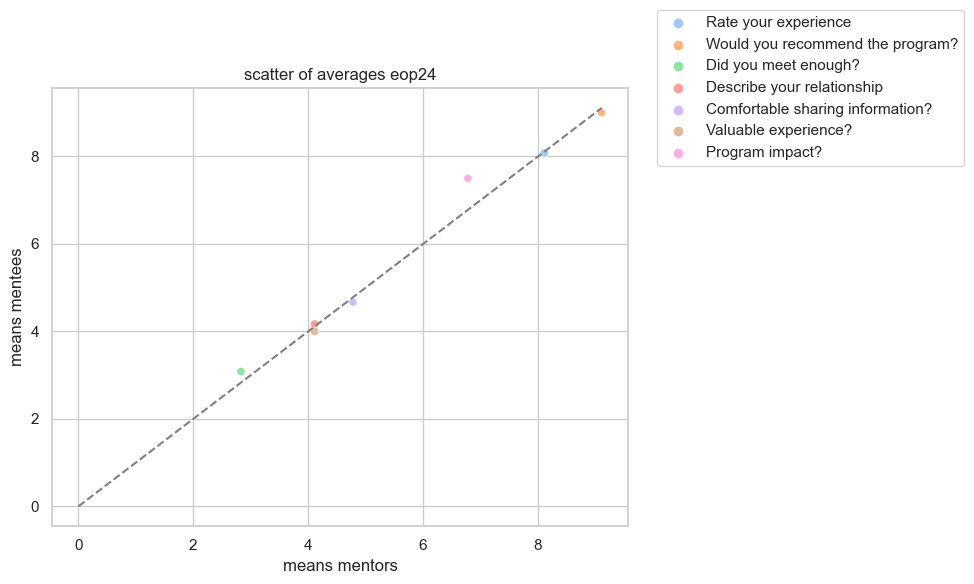

In [72]:
scatter_means(merged_df, label='eop', year='24')

In the end of the same year, there seem to be more alignment than there was in the midterm survey. The only outlier is the "program's impact" which similarly to the midterm survey, was higher for mentees compared to mentors.

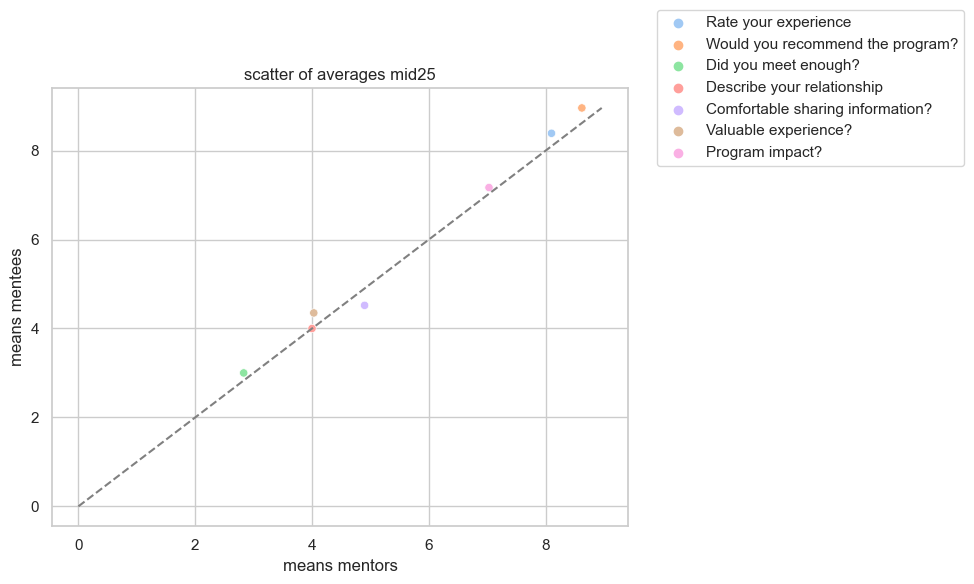

In [75]:
scatter_means(merged_df, label='mid', year='25')

Midterm 2025 shows a general alignment between mentors' and mentees' means, without any outliers that should be addressed. 

## Analysis of Questions

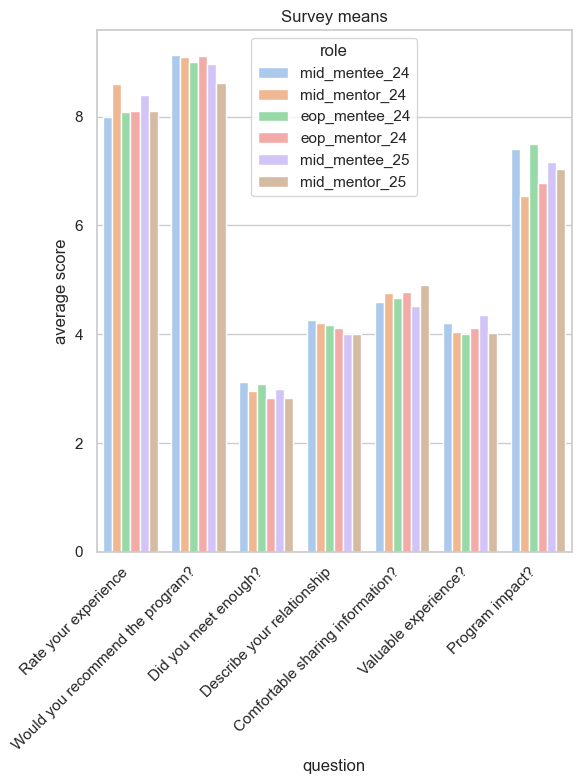

In [77]:
def bar_means(df): 
    melted = df.melt(id_vars='questions', var_name= 'role', value_name = 'average score')
    plt.figure(figsize=(6,8))
    ax = sns.barplot(data = melted, x='questions', y = 'average score', hue='role', palette = 'pastel')
    ax.set_title('Survey means')
    ax.set_xlabel('question')
    ax.set_ylabel('average score')
    ax.legend(title='role')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

bar_means(merged_df)

The bar plot shows the means comparison for each of the questions. 
This plot reinforces the conclusion that the "program's impact" had the highest variation out of all the questions. 
Being the highest for the mentees at the end of 2024 and the lowest for mentors in the middle of 2024.
In 2025, the differences balance out and the responses align more with each other

## Merge mentor & mentee for comparison

In [97]:
def merge_mentor_mentee(matches, mentees_data, mentors_data):
    merged = (matches.merge(mentees_data, left_on='Mentee Name', right_on='Your Name')
    .merge(mentors_data, left_on='Mentor Name', right_on='Your Name', suffixes=('_mentee', '_mentor')))
    
    merged.drop(columns=['Your Name_mentee', 'Your Name_mentor'], inplace=True)
    merged.fillna(-1, inplace=True)
    return merged

datasets = {'mentor_mentee_24_mid': (matches_24, mid_mentee_24, mid_mentor_24),
            'mentor_mentee_24_eop': (matches_24, eop_mentee_24, eop_mentor_24),
            'mentor_mentee_25_mid': (matches_25, mid_mentee_25, mid_mentor_25)}

results = {name: merge_mentor_mentee(matches, mentees, mentors) for name, (matches, mentees, mentors) in datasets.items()}
type(results['mentor_mentee_24_mid']) 
results['mentor_mentee_24_mid'].head() 

,Mentor Name,Mentee Name,Timestamp_mentee,Rate your experience_mentee,Would you recommend the program?_mentee,Would you consider serving as a mentor?_mentee,Were the articles helpful?_mentee,How often did you meet?_mentee,Did you meet enough?_mentee,Describe your relationship_mentee,...,Were the articles helpful?_mentor,How often did you meet?_mentor,Did you meet enough?_mentor,Describe your relationship_mentor,Comfortable sharing information?_mentor,Valuable experience?_mentor,Most satisfying thing?_mentor,Program impact?_mentor,Impact text_mentor,Suggestions for improvement_mentor
0,Alexandra Rubinov,Juliana Wise,4/16/2024 14:13:33,10,10,Yes,Yes,Every other week,5,5,...,Yes,Every other week,2,5,5,5,Seeing my mentee light up at every meeting whe...,7,-1,-1
1,Ken Oestreich,Megan Cohen,4/24/2024 12:16:08,9,10,No,Yes,Once a week,4,5,...,Yes,Once a week,3,5,5,5,"Excellent matching, guidance, community-building",9,"My mentee is in their first job out of school,...",Publicise it more broadly!
2,David Gaertner,Ben Shamon,4/10/2024 13:52:03,8,10,Yes,No,Every other week,3,5,...,Yes,Every other week,3,5,5,5,"Being able to help, to think about things I ha...",7,He was pretty good to begin with,-1
3,Arik Paran,Danielle Heller,4/12/2024 12:39:23,8,10,Possibly,Yes,Once a month,2,4,...,Yes,Every other week,3,4,5,3,Coming up with new ideas,7,My current mantee is looking for work without ...,The program is fine I am not sure I want to to...
4,Sam Szteinbaum,Rachel Sklar,4/10/2024 11:08:13,6,7,No,Yes,Once a month,2,4,...,Yes,Once a month,3,4,5,4,Providing a sounding board to mentee,4,She has not been able to significantly improve...,-1


### Visualizations- histogram of distributions

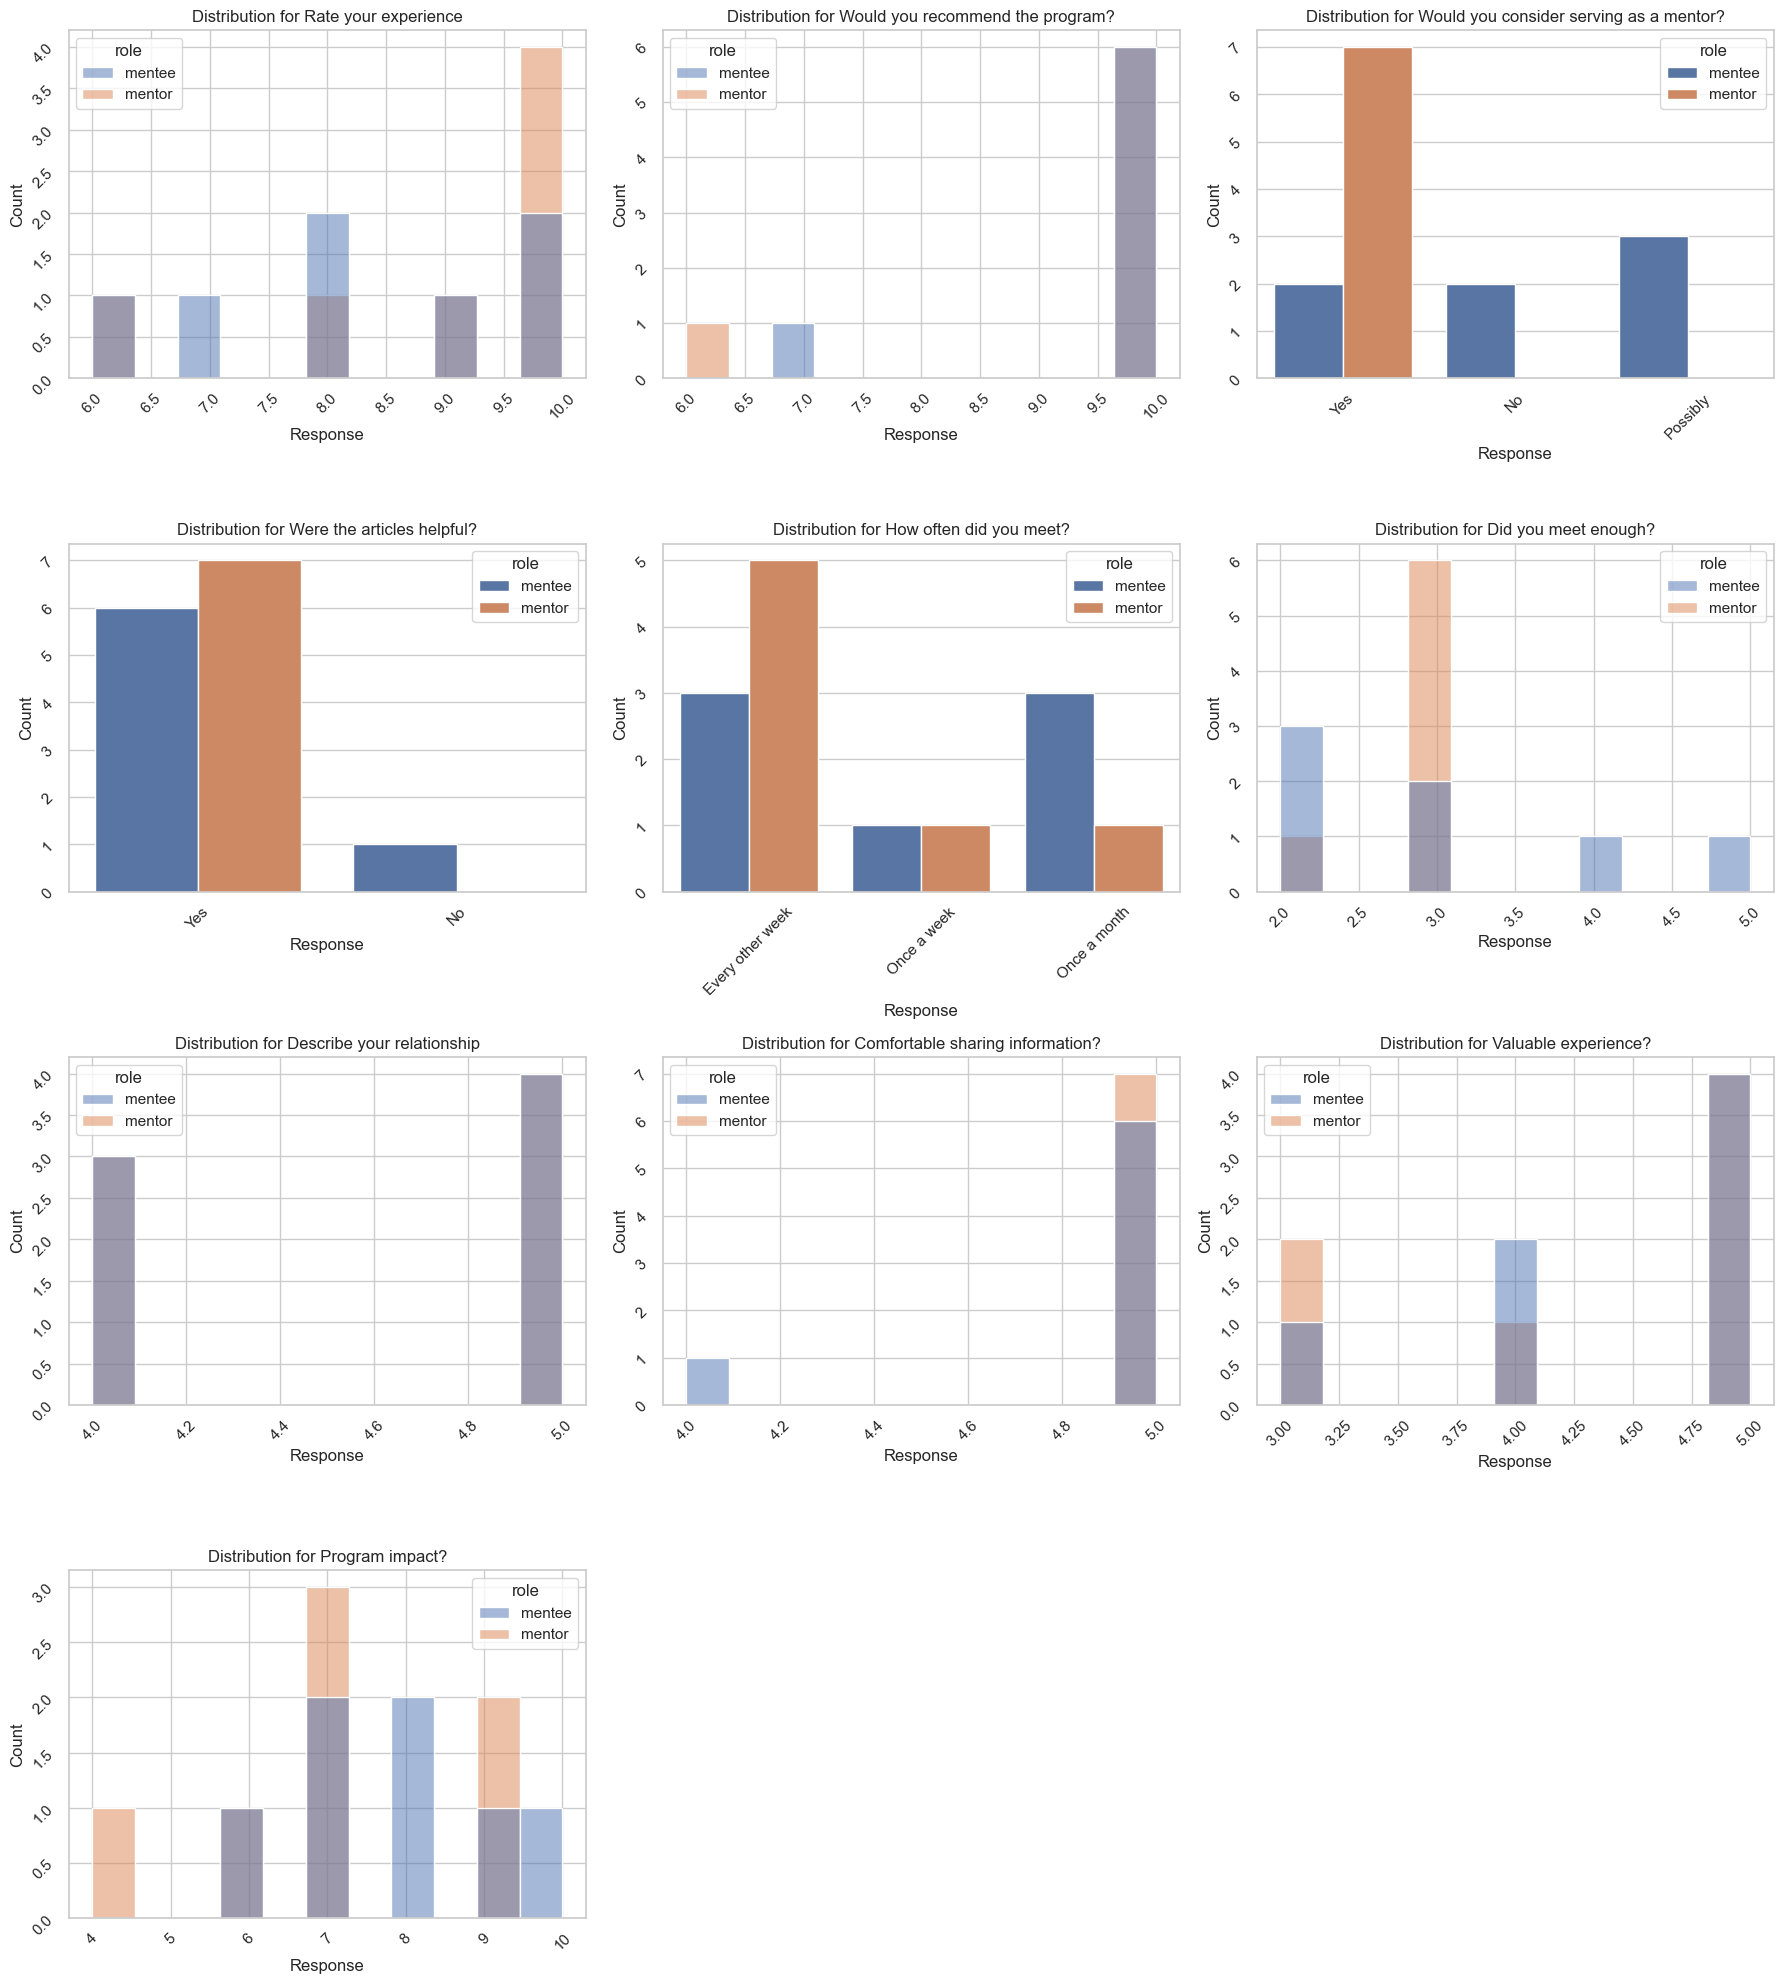

In [105]:
def distributions(df):
    warnings.filterwarnings('ignore', category=FutureWarning)
    mentee_cols = [col for col in df.columns if '_mentee' in col and 'Timestamp' not in col]
    mentor_cols = [col for col in df.columns if '_mentor' in col and 'Timestamp' not in col]
    mentee_df = df[['Mentee Name'] + mentee_cols].melt(id_vars='Mentee Name', var_name='question', value_name='response')
    mentee_df['role'] = 'mentee'
    mentee_df['question'] = mentee_df['question'].str.replace('_mentee', '', regex=False)

    mentor_df = df[['Mentor Name'] + mentor_cols].melt(id_vars='Mentor Name', var_name='question', value_name='response')
    mentor_df['role'] = 'mentor'
    mentor_df['question'] = mentor_df['question'].str.replace('_mentor', '', regex=False)

    new_df = pd.concat([mentee_df.rename(columns = {'Mentee Name': 'name'}),
                        mentor_df.rename(columns = {'Mentor Name': 'name'})])

    questions = new_df['question'].unique()
    n_unique = len(questions)
    n_cols = 3
    n_rows = -(-n_unique//n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
    axes = axes.flatten()
    
    for i, q in enumerate(questions):
        ax = axes[i]
        temp = new_df[new_df['question'] == q].copy()
        try:
            temp['response'] = pd.to_numeric(temp['response'])
            temp = temp.dropna(subset=['response'])
            plt_type = 'numeric'
        except:
            temp['response'] = temp['response'].astype(str).fillna('Missing')
            plt_type = 'categorical'

        if plt_type == 'numeric':
            sns.histplot(data=temp, x='response', hue='role', bins =11, ax=ax)
        else:
            sns.countplot(data=temp, x='response', hue='role', ax=ax)

        ax.set_title(f'Distribution for {q}')
        ax.set_xlabel('Response')
        ax.set_ylabel('Count')
        ax.tick_params(rotation=45)

    for j in range(i+1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

distributions(results['mentor_mentee_24_mid'].drop(columns = ['Most satisfying thing?_mentee', 'Impact text_mentee', 'Suggestions for improvement_mentee',
                                              'Most satisfying thing?_mentor', 'Impact text_mentor', 'Suggestions for improvement_mentor']))

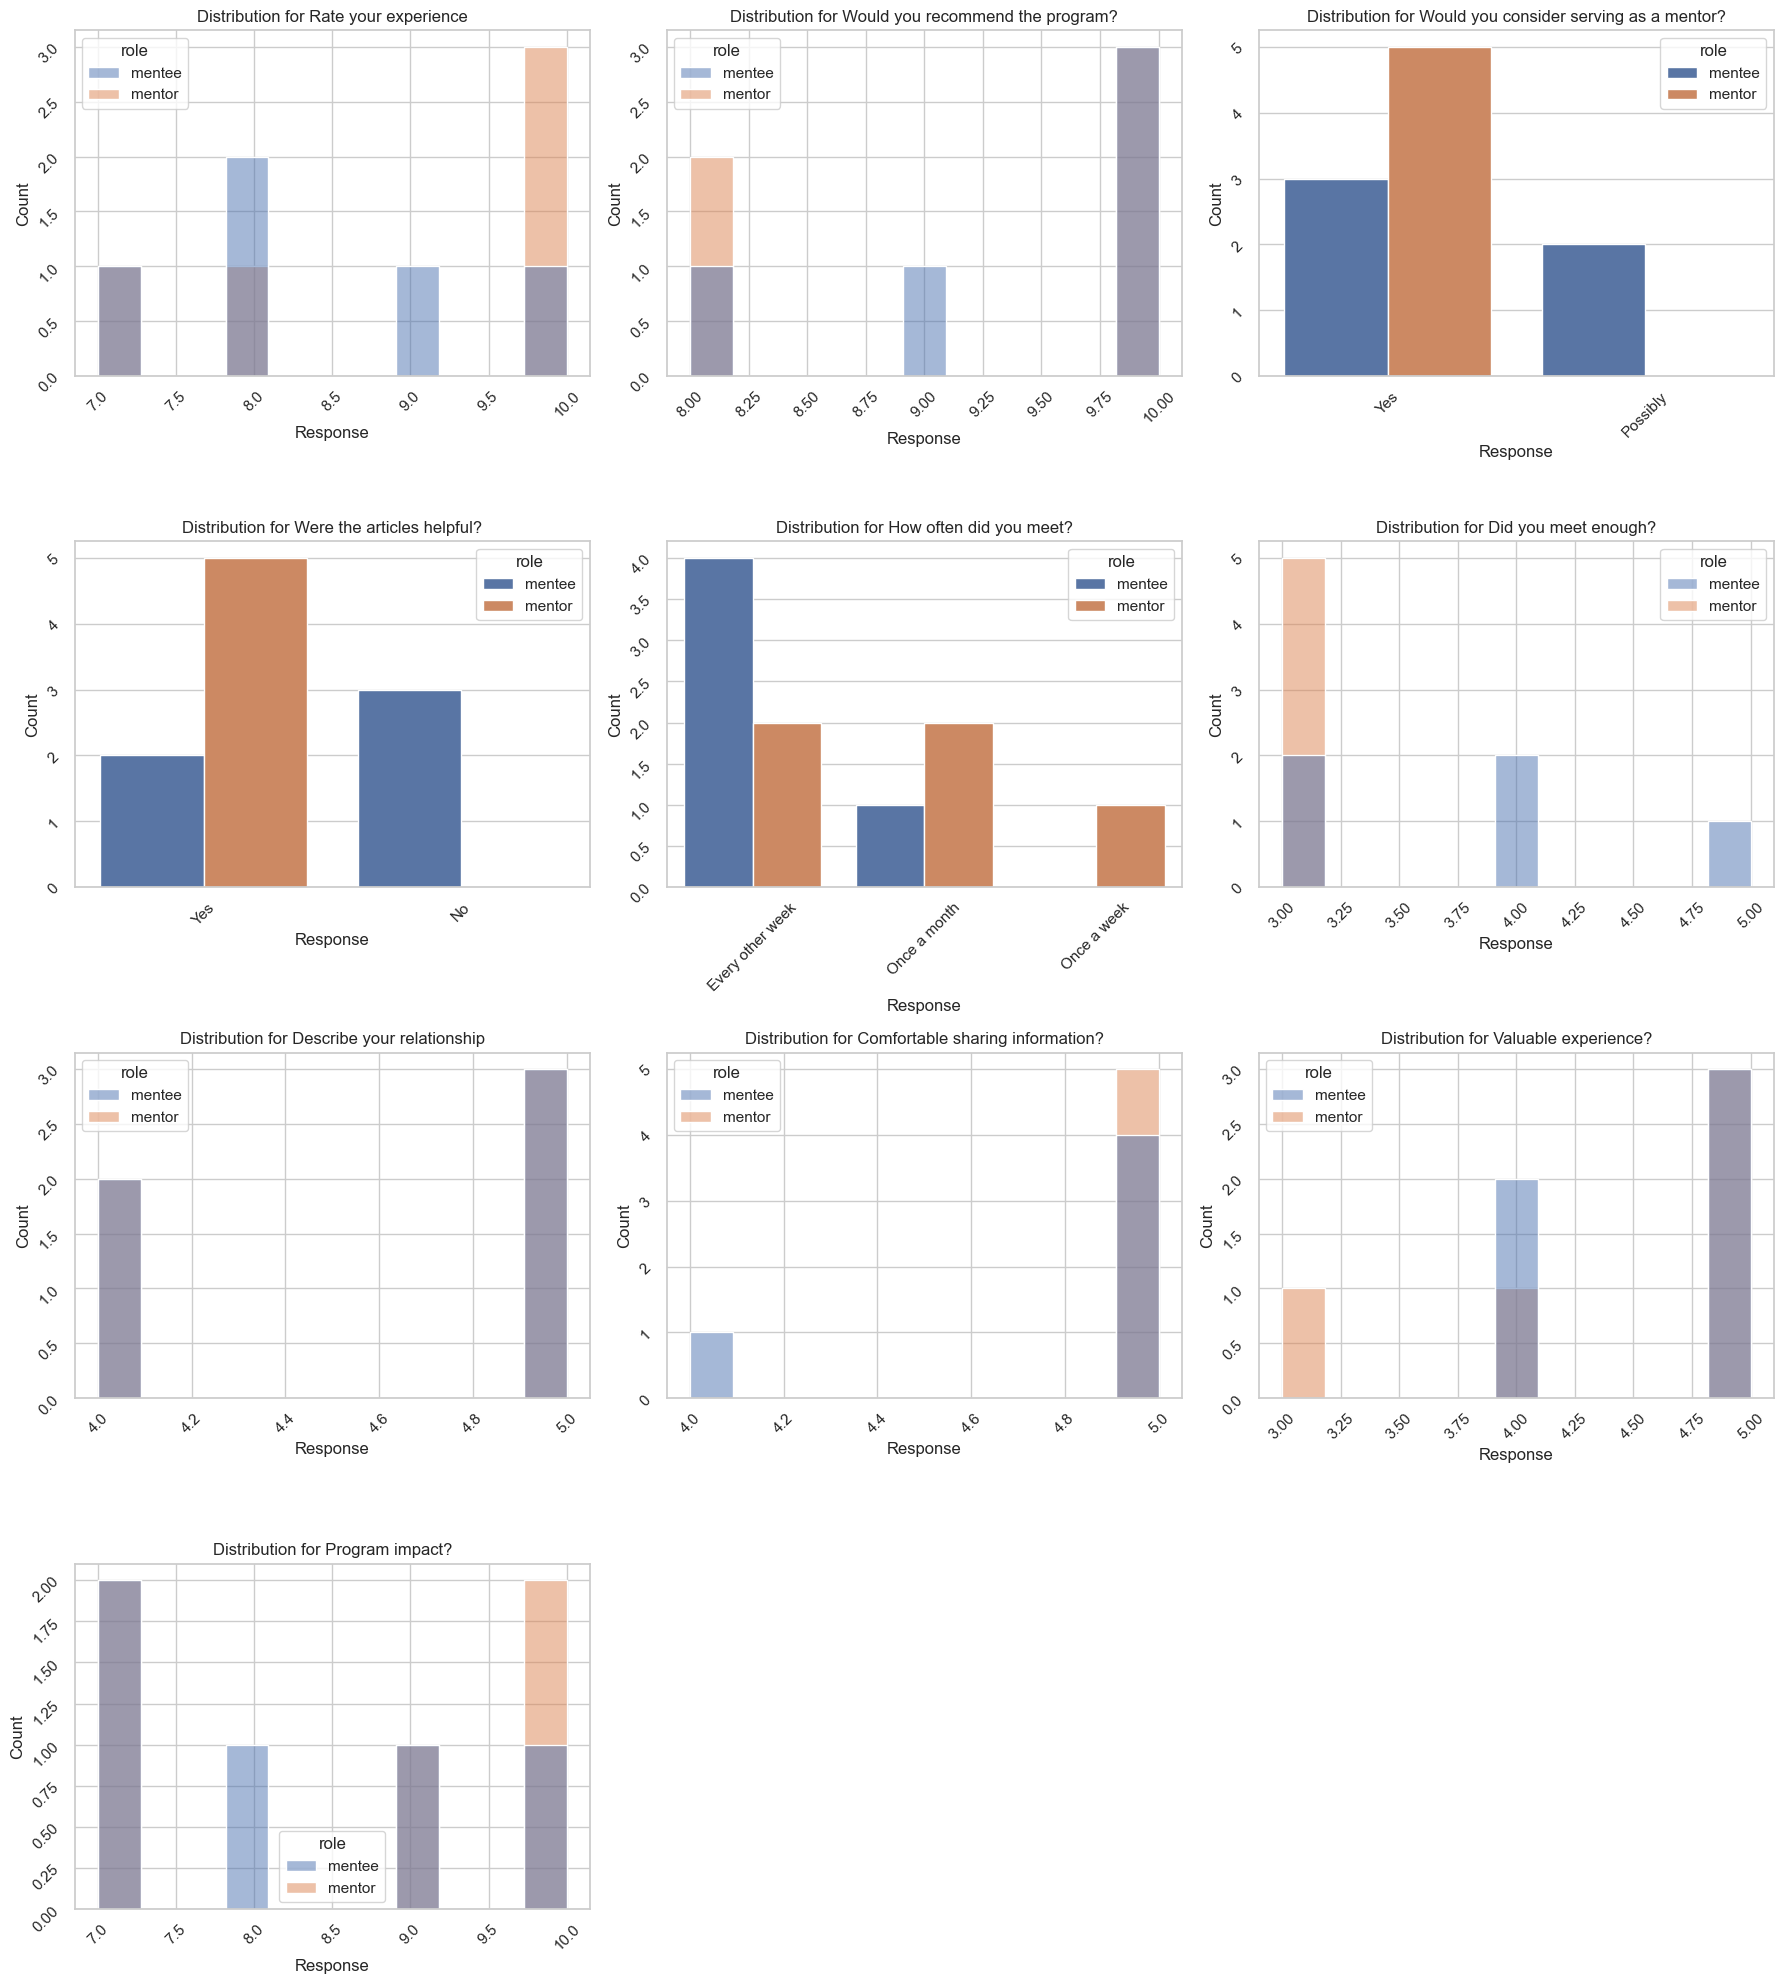

In [107]:
distributions(results['mentor_mentee_24_eop'].drop(columns = ['Most satisfying thing?_mentee', 'Impact text_mentee', 'Suggestions for improvement_mentee',
                                                   'Most satisfying thing?_mentor', 'Impact text_mentor', 'Suggestions for improvement_mentor']))

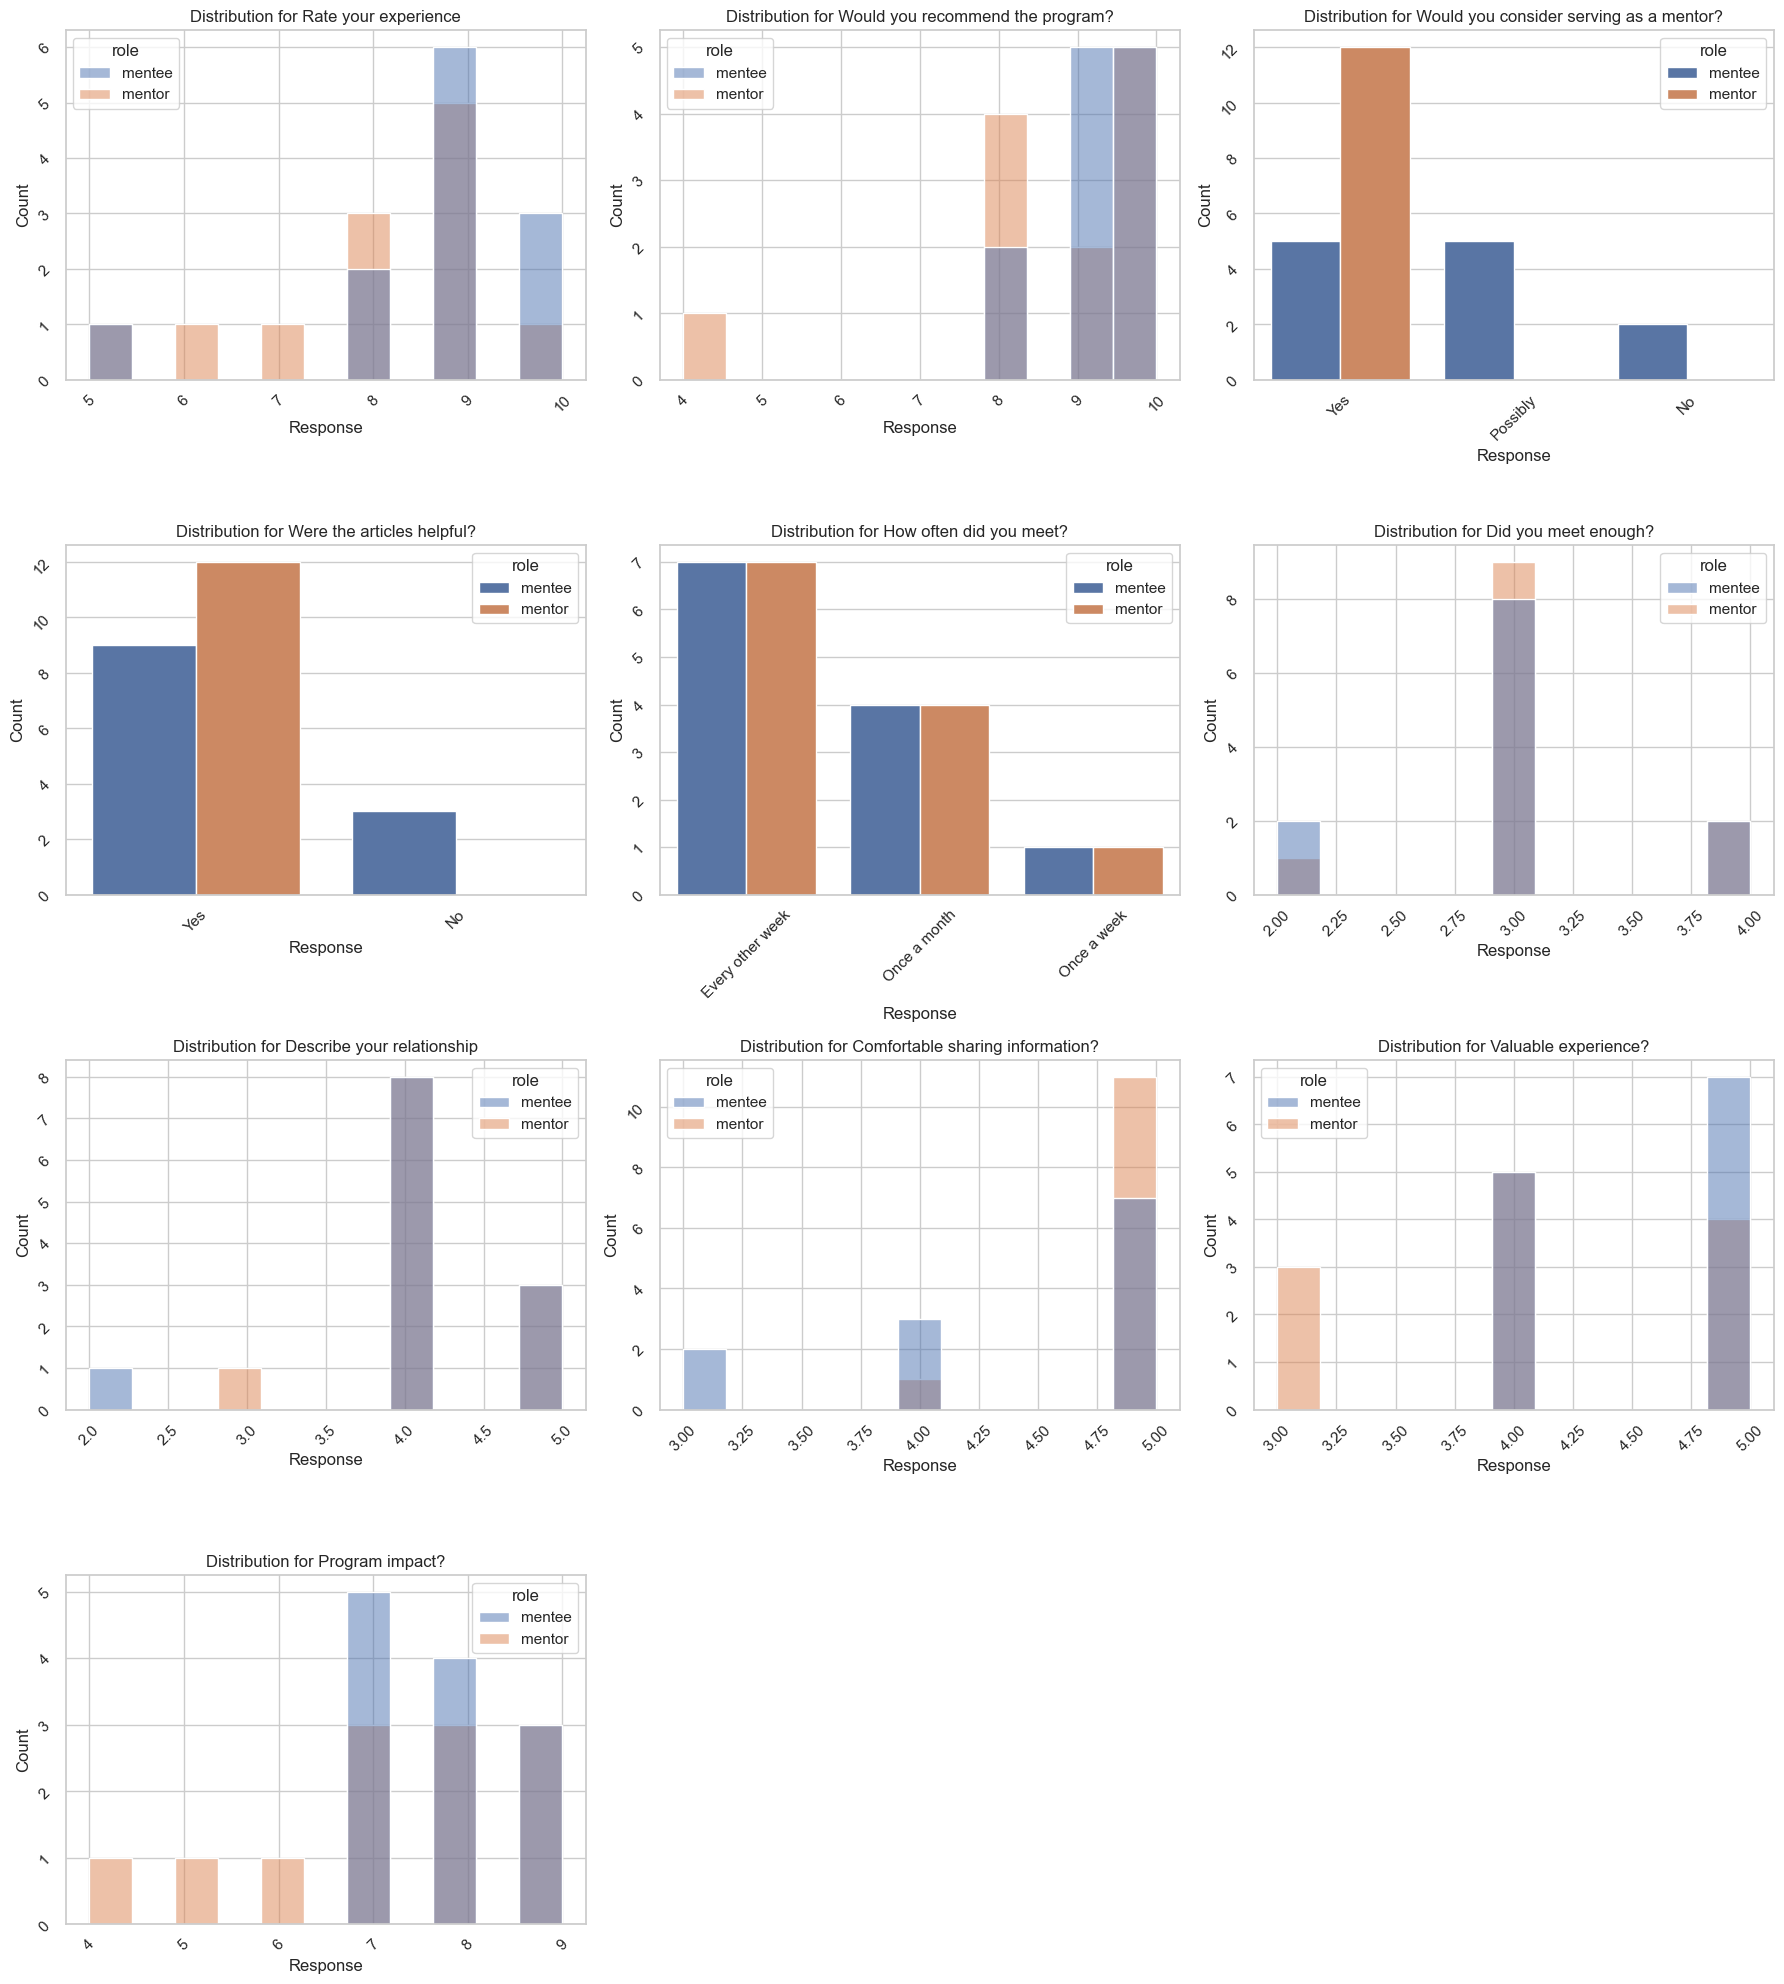

In [111]:
distributions(results['mentor_mentee_25_mid'].drop(columns = ['Most satisfying thing?_mentee', 'Impact text_mentee', 'Suggestions for improvement_mentee',
                                              'Most satisfying thing?_mentor', 'Impact text_mentor', 'Suggestions for improvement_mentor']))

## Mentors-Mentees Responses to specific questions
The plots below show the mentor-mentee relationship in their responses. The X axis reprensents mentor response, while the Y axis represents mentee response. The straight line indiciate perfect correlati9on while deviations from the line show mismatch between the asnwers. Every point represents a specific pair of a mentor and mentee. 

### Scatter of midterm survey, 2024

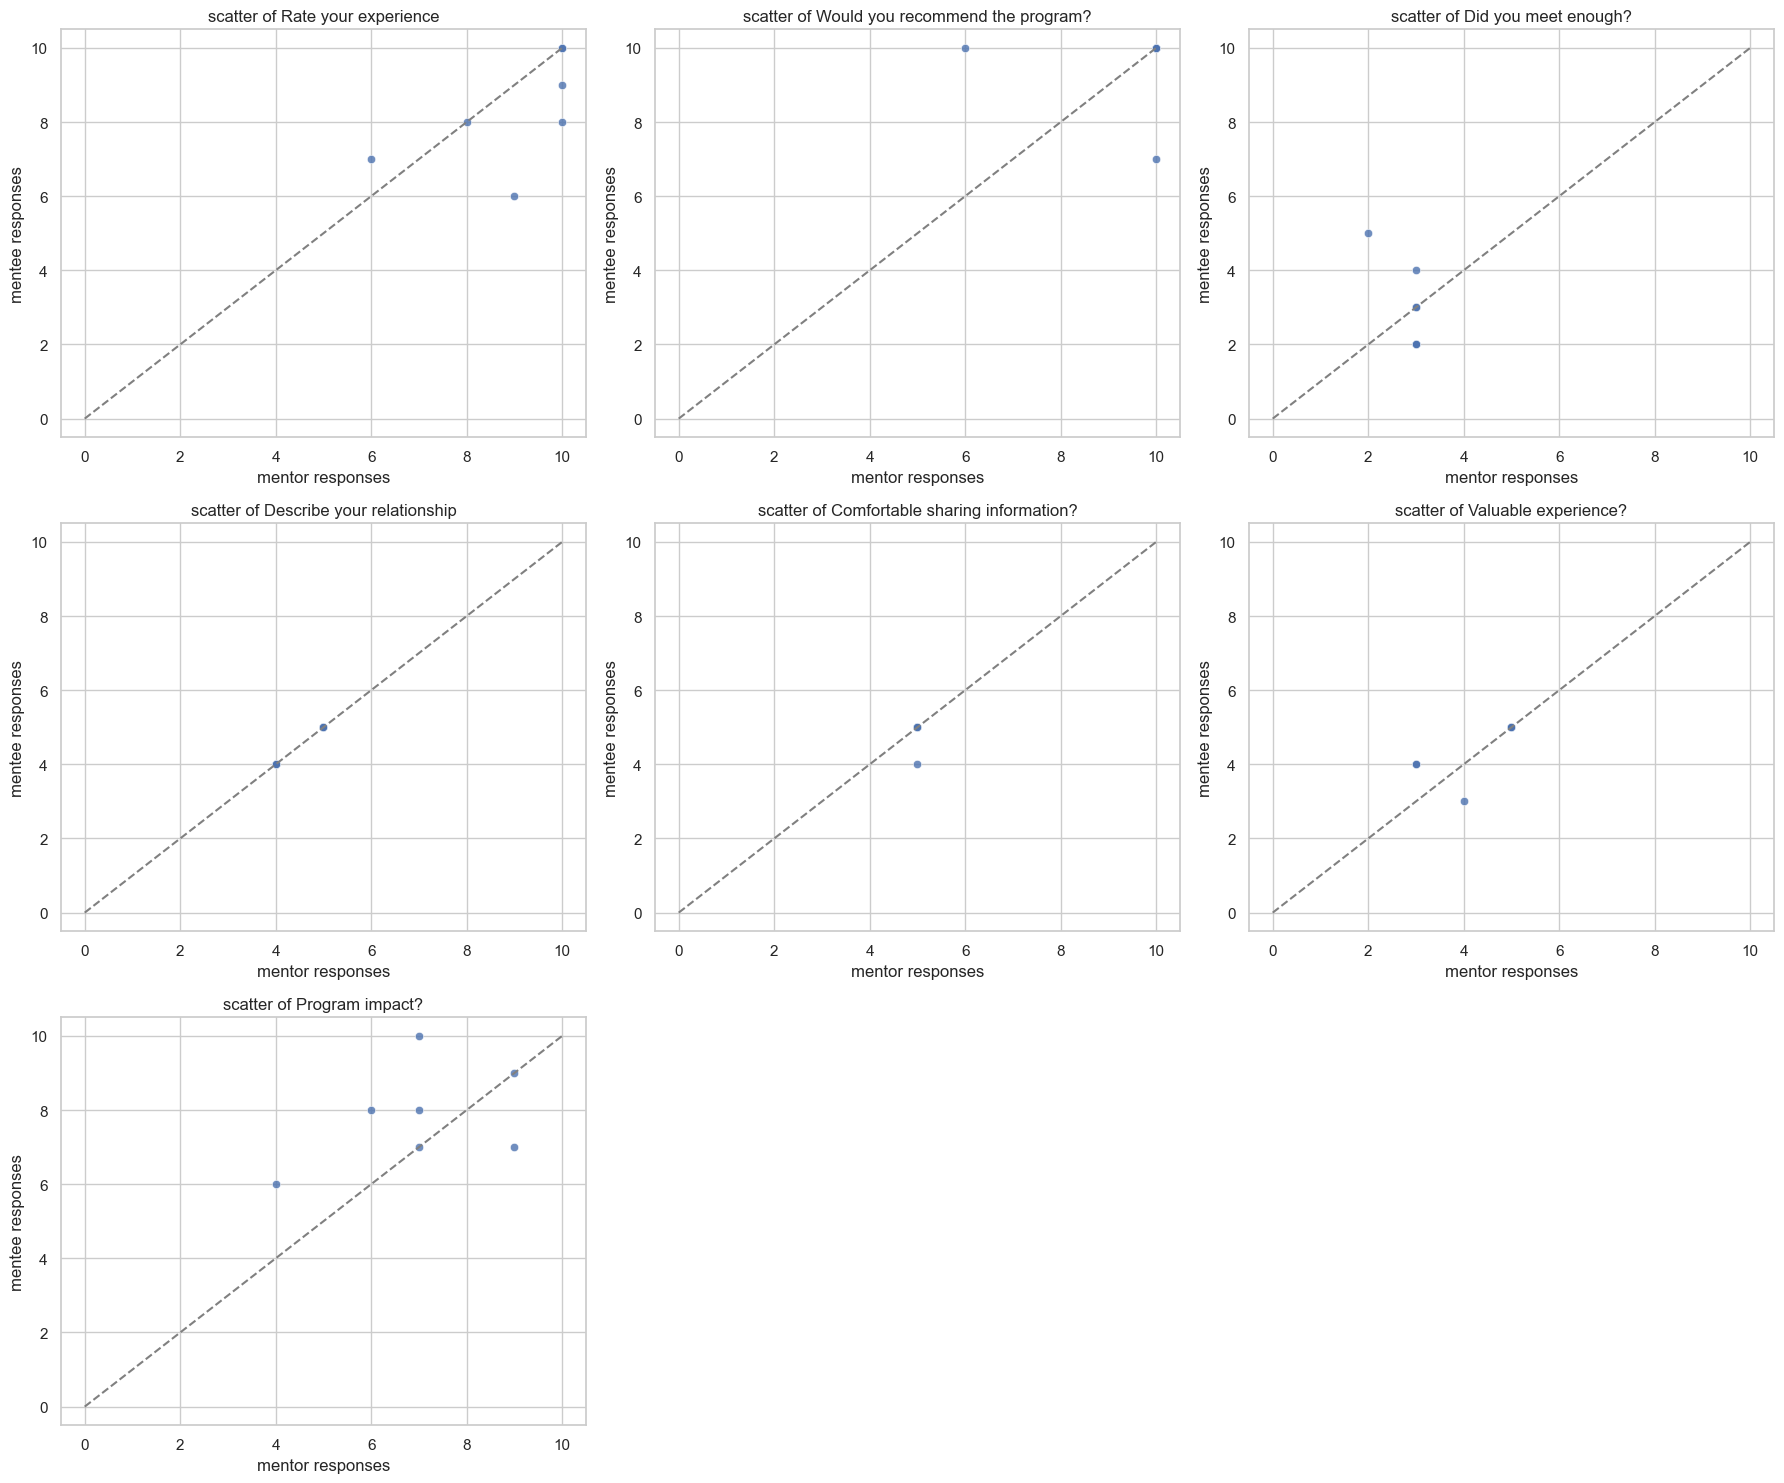

In [123]:
def scatt_diff(df):
    df.dropna()
    cols = ['Rate your experience',
       'Would you recommend the program?', 
       'Did you meet enough?', 'Describe your relationship',
       'Comfortable sharing information?',
       'Valuable experience?', 'Program impact?']
    n_cols = 3
    n_rows = -(-len(cols)//n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
    axes = axes.flatten()
    for i,q in enumerate(cols):
        new_df = pd.DataFrame({'question': q, 'Mentee Name': df['Mentee Name'], 'response mentee': df[q + '_mentee'], 
                           'Mentor Name': df['Mentor Name'], 'response mentor': df[q + '_mentor']})
        sns.scatterplot(data=new_df, x = 'response mentor', y = 'response mentee', alpha=0.8, ax=axes[i])
        axes[i].plot([0, 10], [0, 10], '--', color = 'gray')
        axes[i].set_xlabel('mentor responses')
        axes[i].set_ylabel('mentee responses')
        axes[i].set_title(f'scatter of {q}')

    for j in range(i+1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

scatt_diff(results['mentor_mentee_24_mid'])

### Scatter of end of program survey, 2024

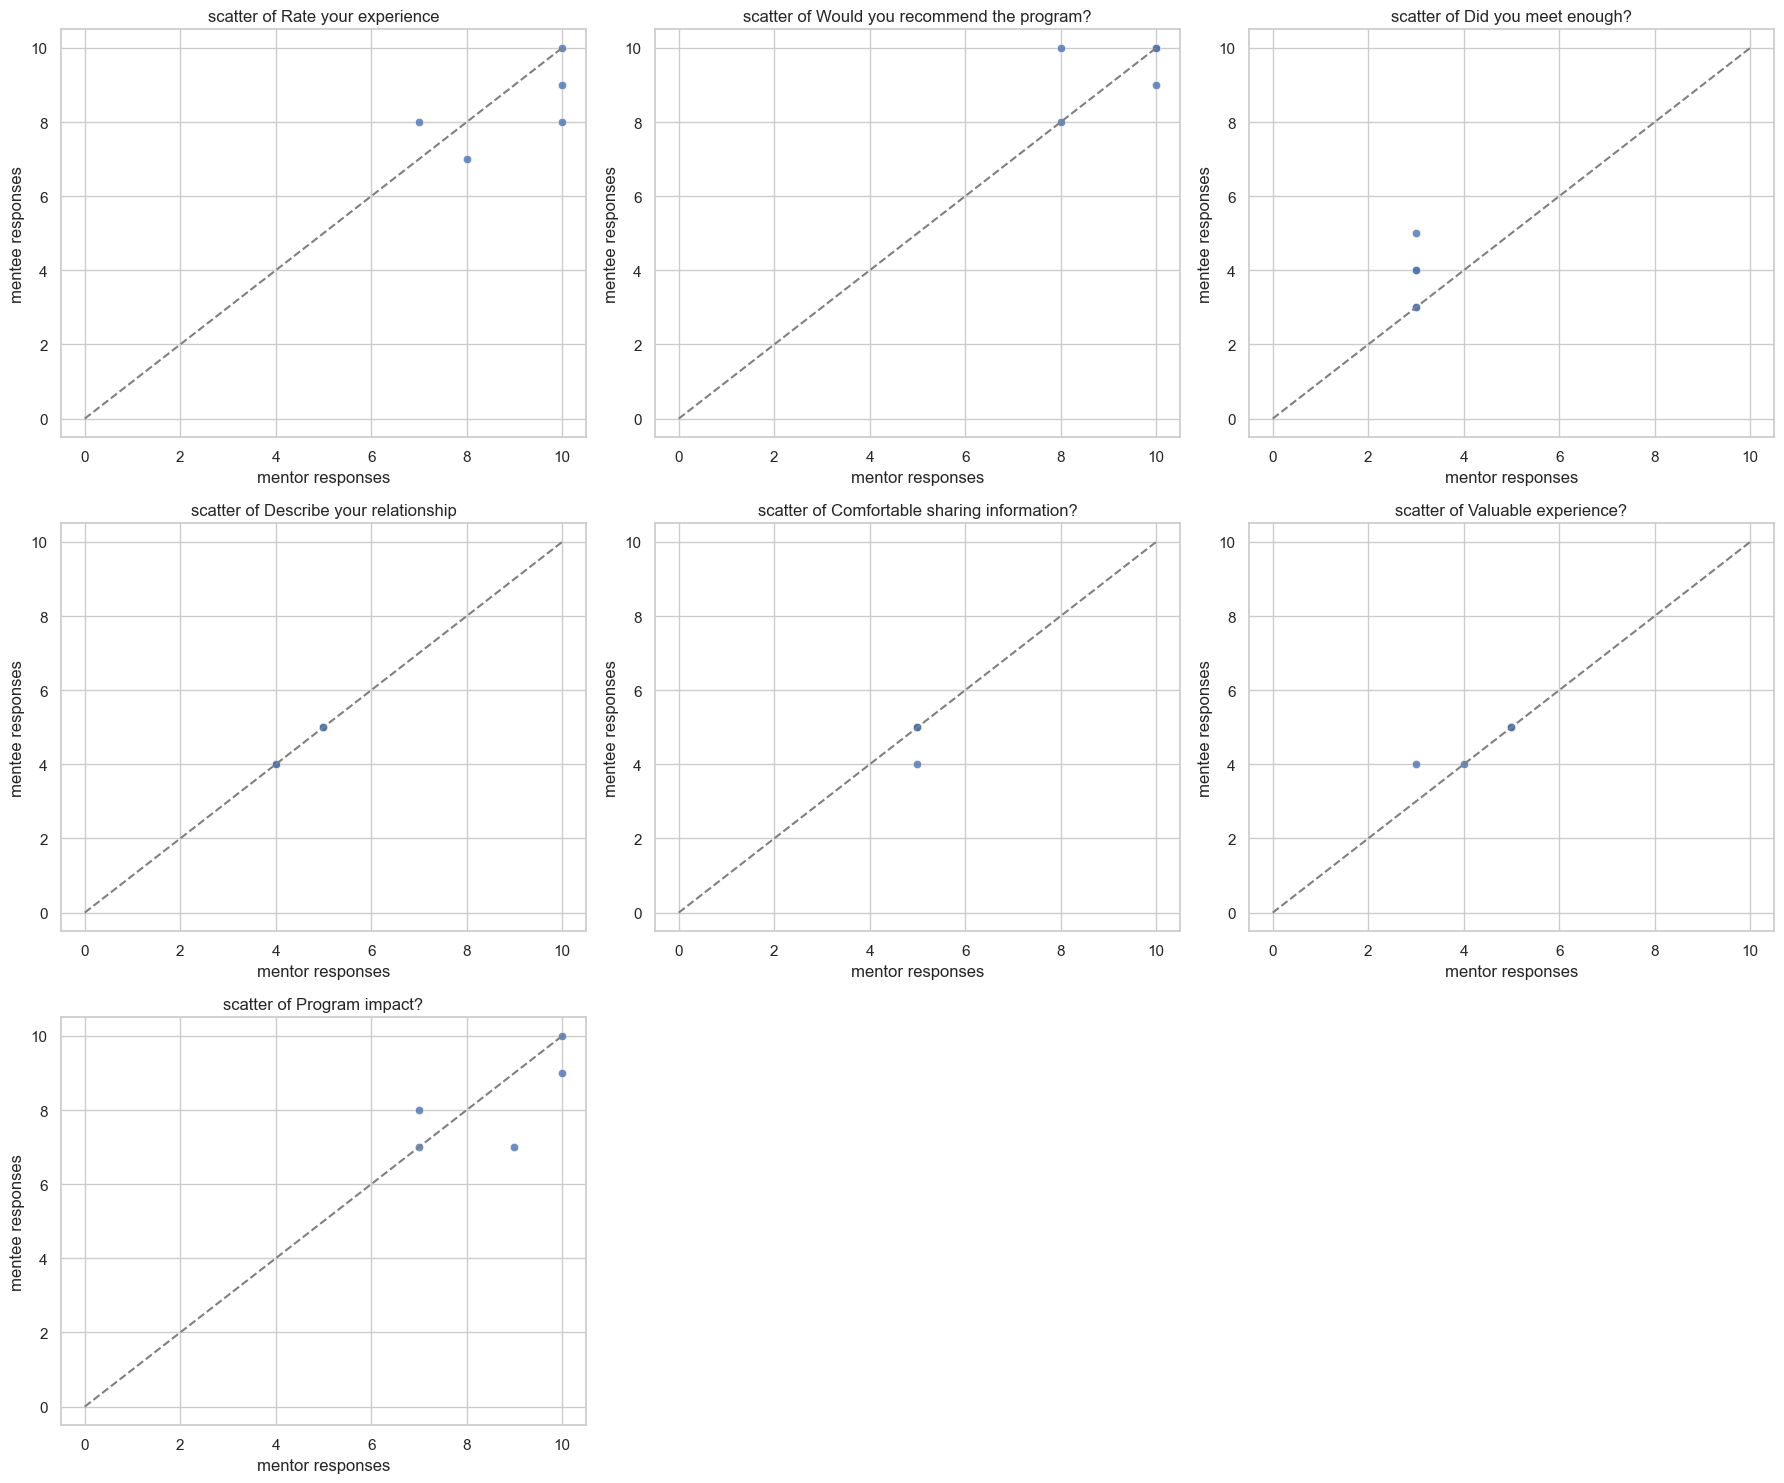

In [126]:
scatt_diff(results['mentor_mentee_24_eop'])

### Scatter of midterm survey, 2025

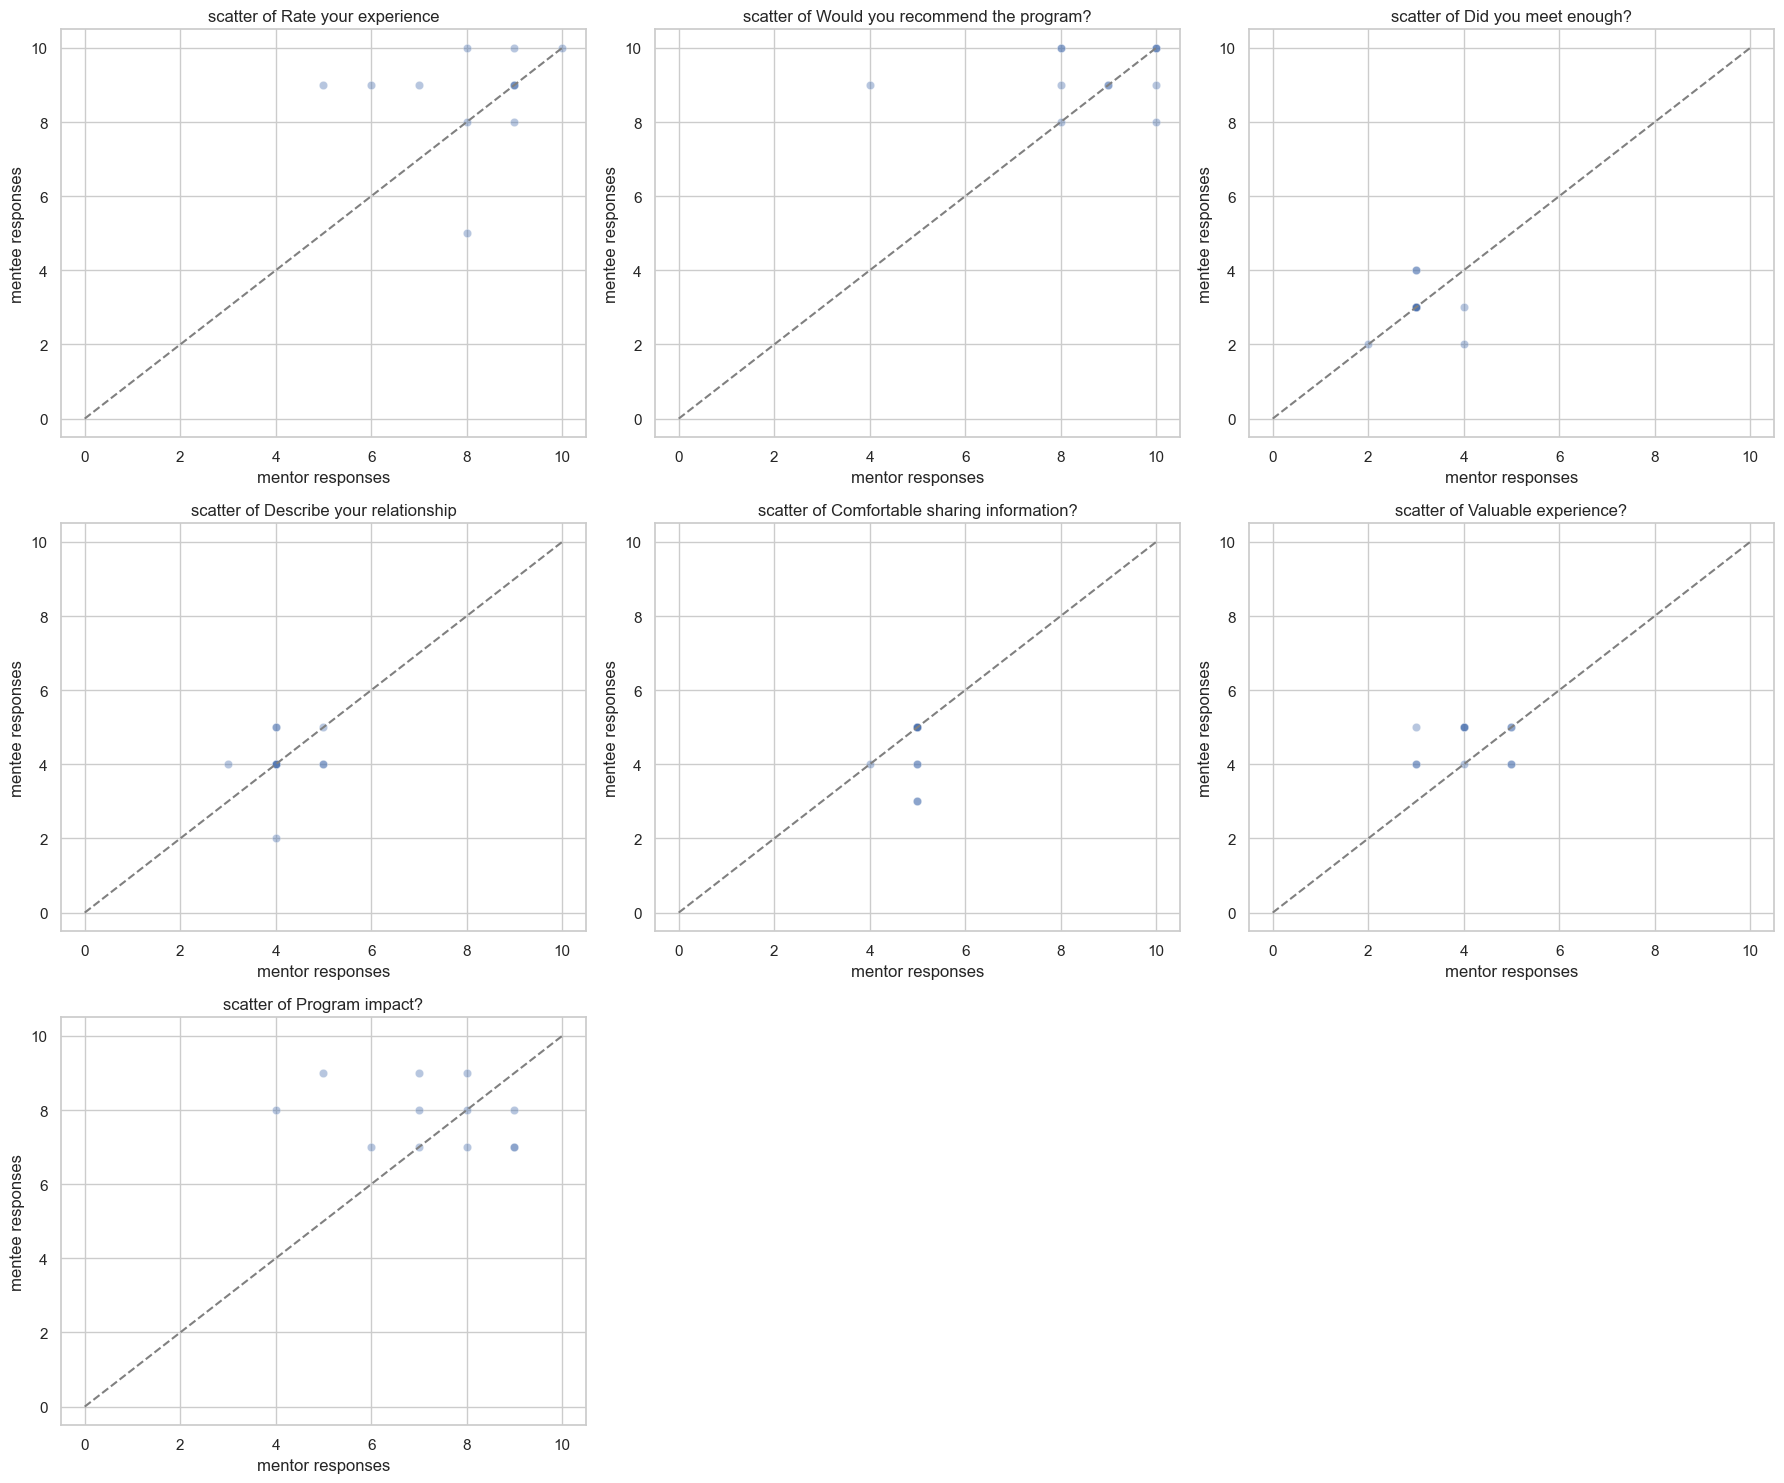

In [121]:
scatt_diff(results['mentor_mentee_25_mid'])

### Pie plot for distributions

In [131]:
def pie_plot(df):
    colors = ['pink', 'blue', 'purple', 'gray']
    df.fillna(-1, inplace=True)
    
    numeric_cols = df.select_dtypes(include=np.number).columns
    num_charts = len(numeric_cols)
    charts_per_row = 3
    num_rows = (num_charts + charts_per_row - 1) // charts_per_row

    fig, axes = plt.subplots(num_rows, charts_per_row, figsize=(charts_per_row * 5, num_rows * 5))
    axes = axes.flatten()  

    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        count8 = (df[col] >= 8).sum()
        count4 = ((df[col] <= 7) & (df[col] > 3)).sum()
        count0 = ((df[col] <= 3) & (df[col] >= 0)).sum()
        count_no_vote = (df[col] == -1.0).sum()

        sizes = [count8, count4, count0, count_no_vote]
        labels = ['8-10', '4-7', '0-3', 'No Vote']
        wedges, texts, autotexts = ax.pie(sizes, colors=colors, autopct='%1.1f%%', textprops={'color':'white'})
        ax.legend(wedges, labels, bbox_to_anchor=(1.1, 0.5))
        name = col.replace('_', ' ')
        ax.set_title(f"{name}")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

## Distribution of repsponses 
The pie plots shows the distribution of responses out of those who voted. It is important to highlight that a large precentage of participants haven't responded to the survey, therefore the data represented in the pie plots is not a representation of all the participants of the mentorship program.

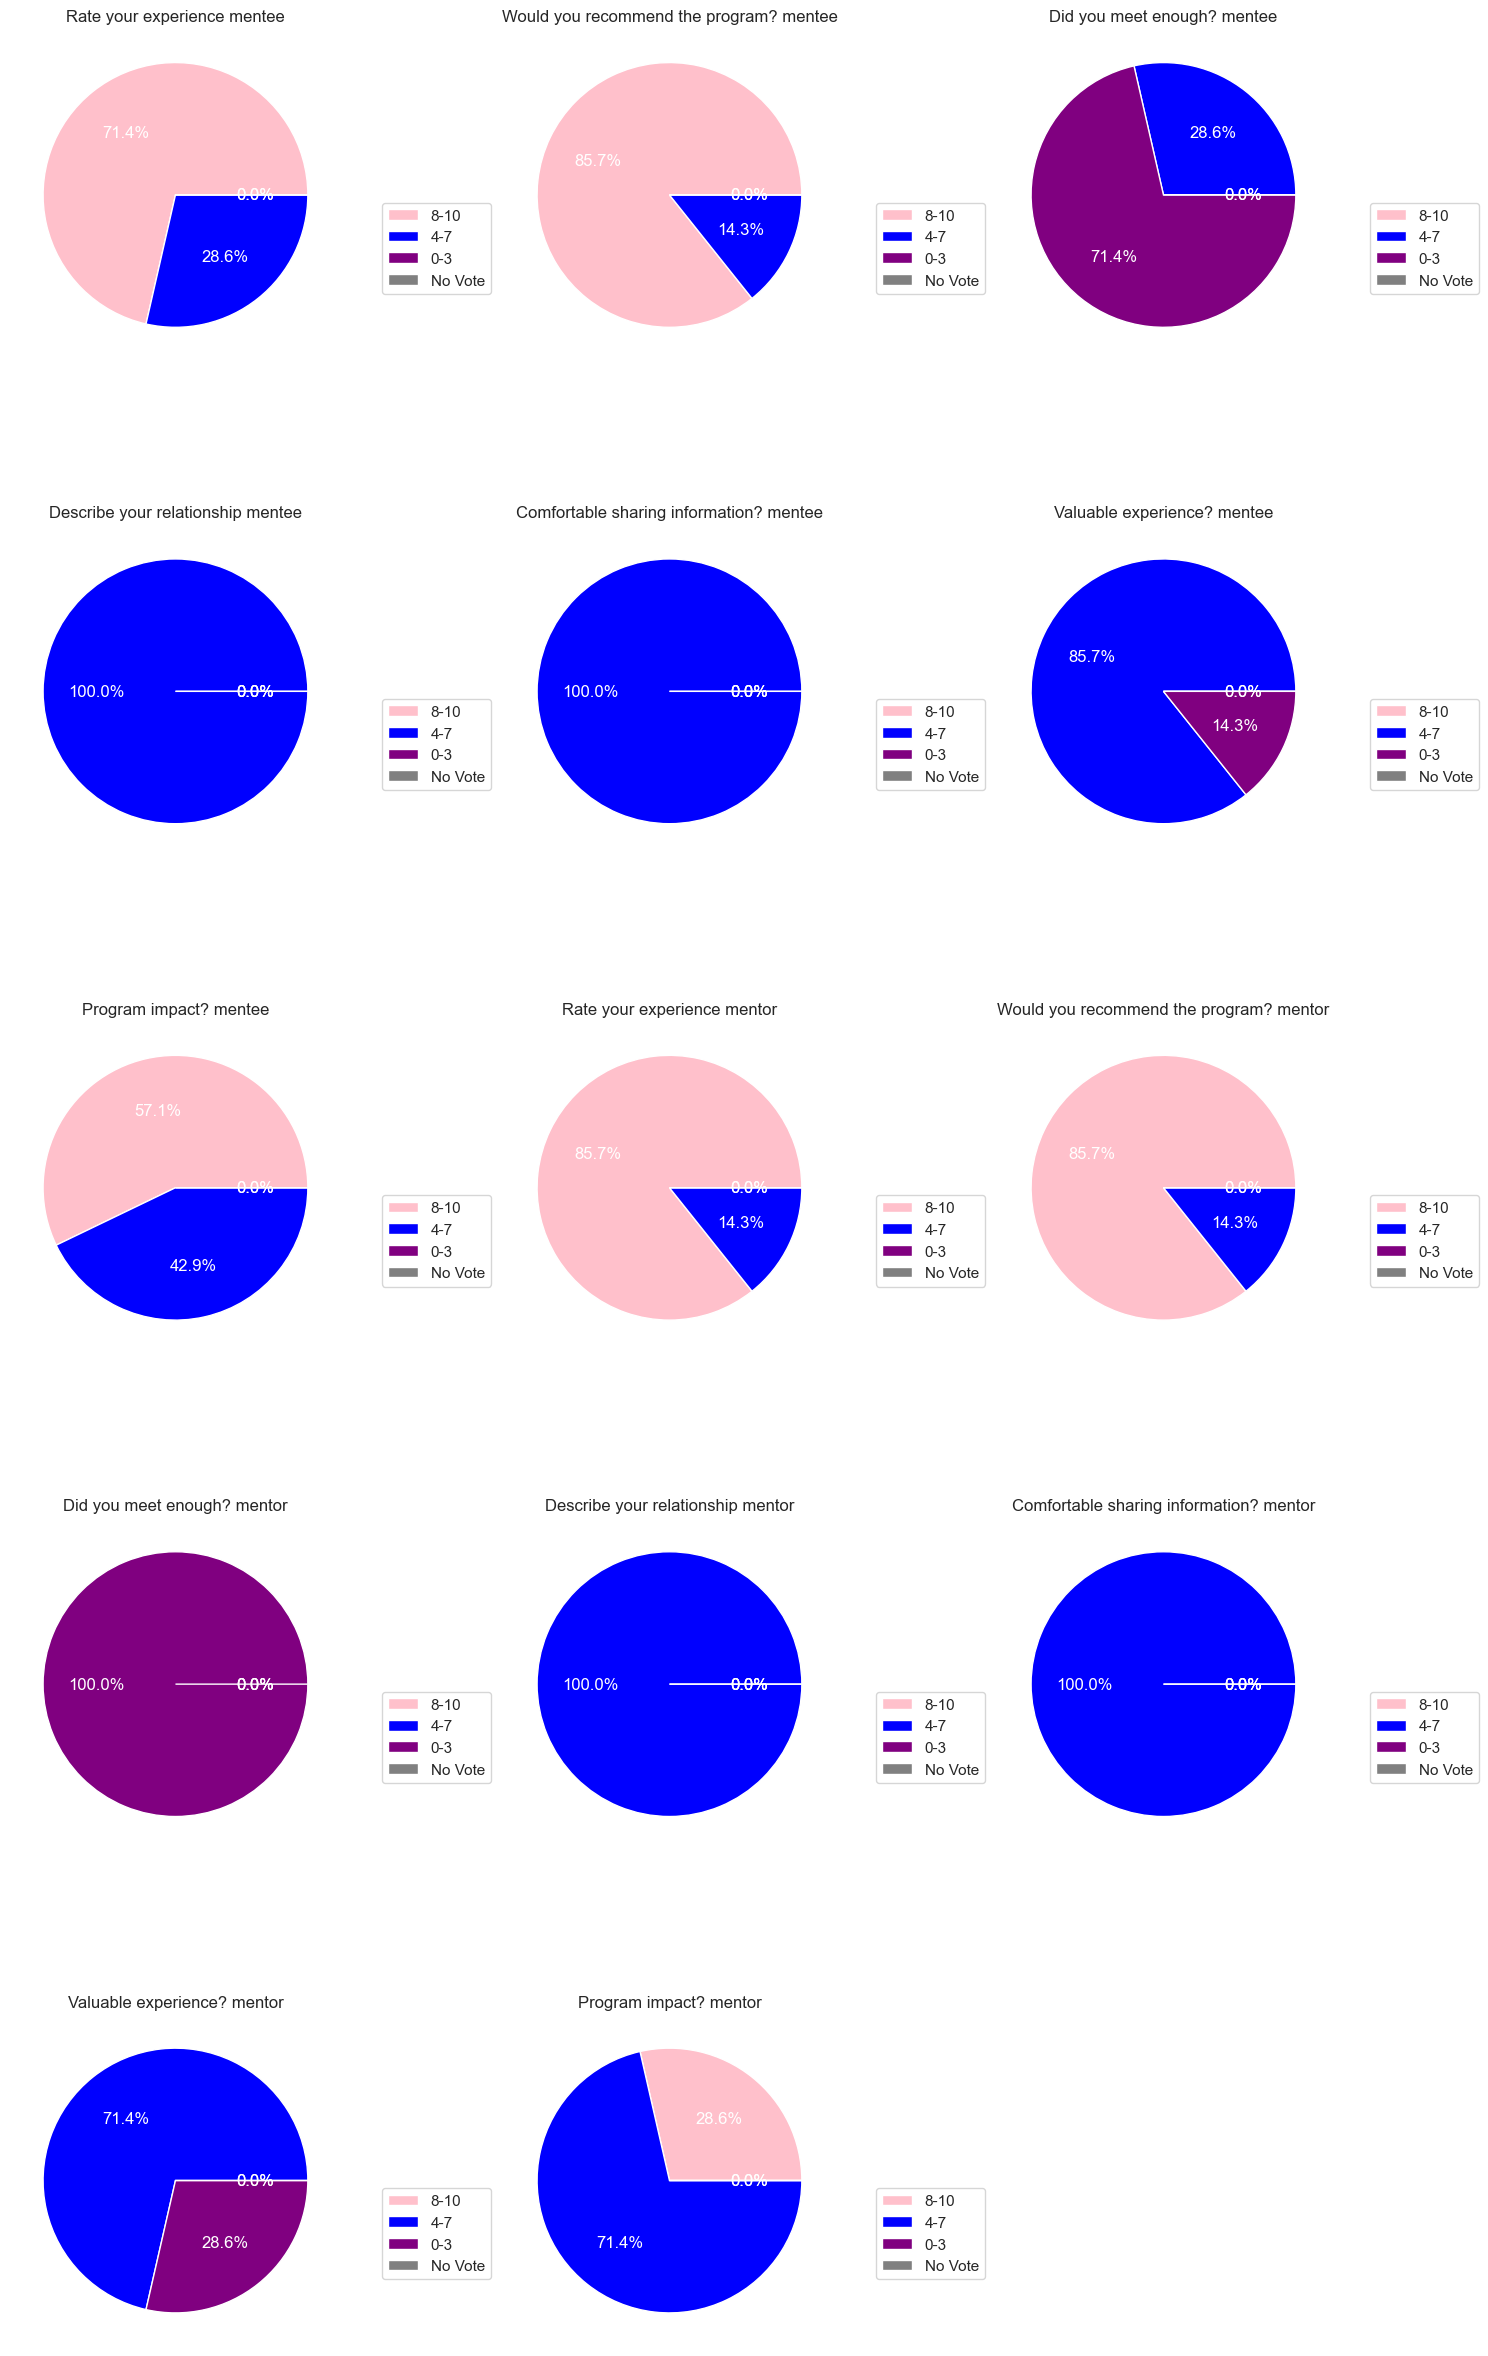

In [134]:
pie_plot(results['mentor_mentee_24_mid'])

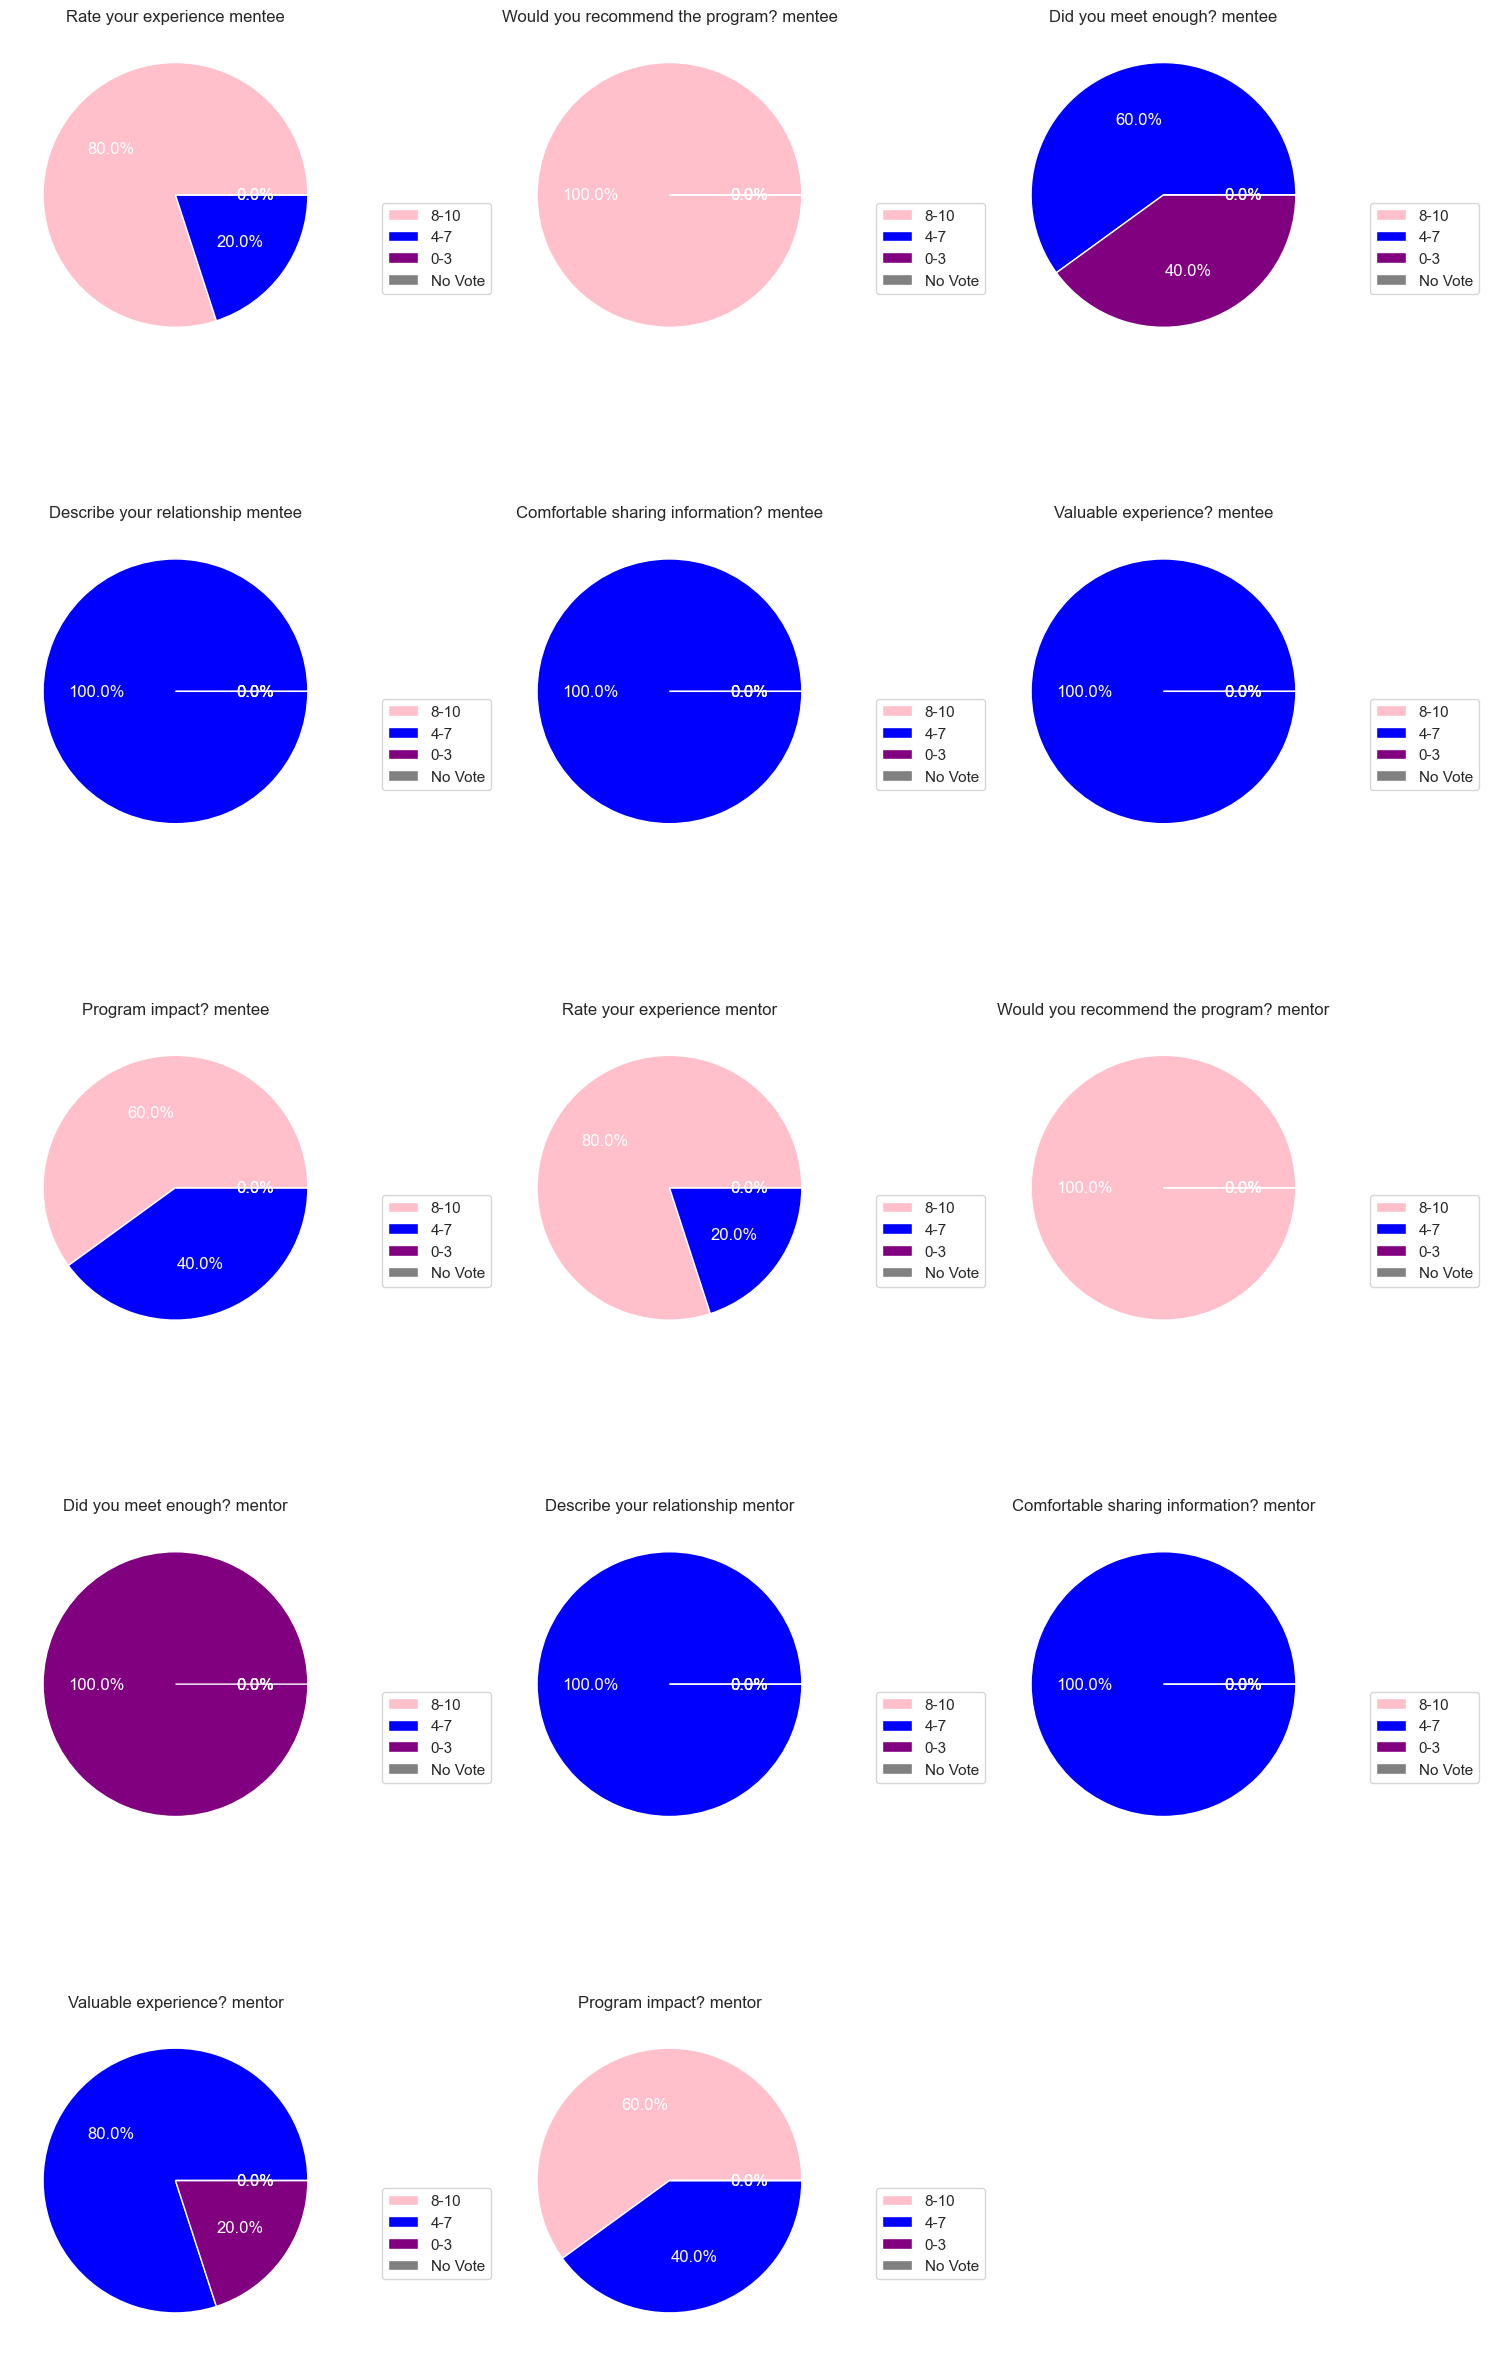

In [136]:
pie_plot(results['mentor_mentee_24_eop'])

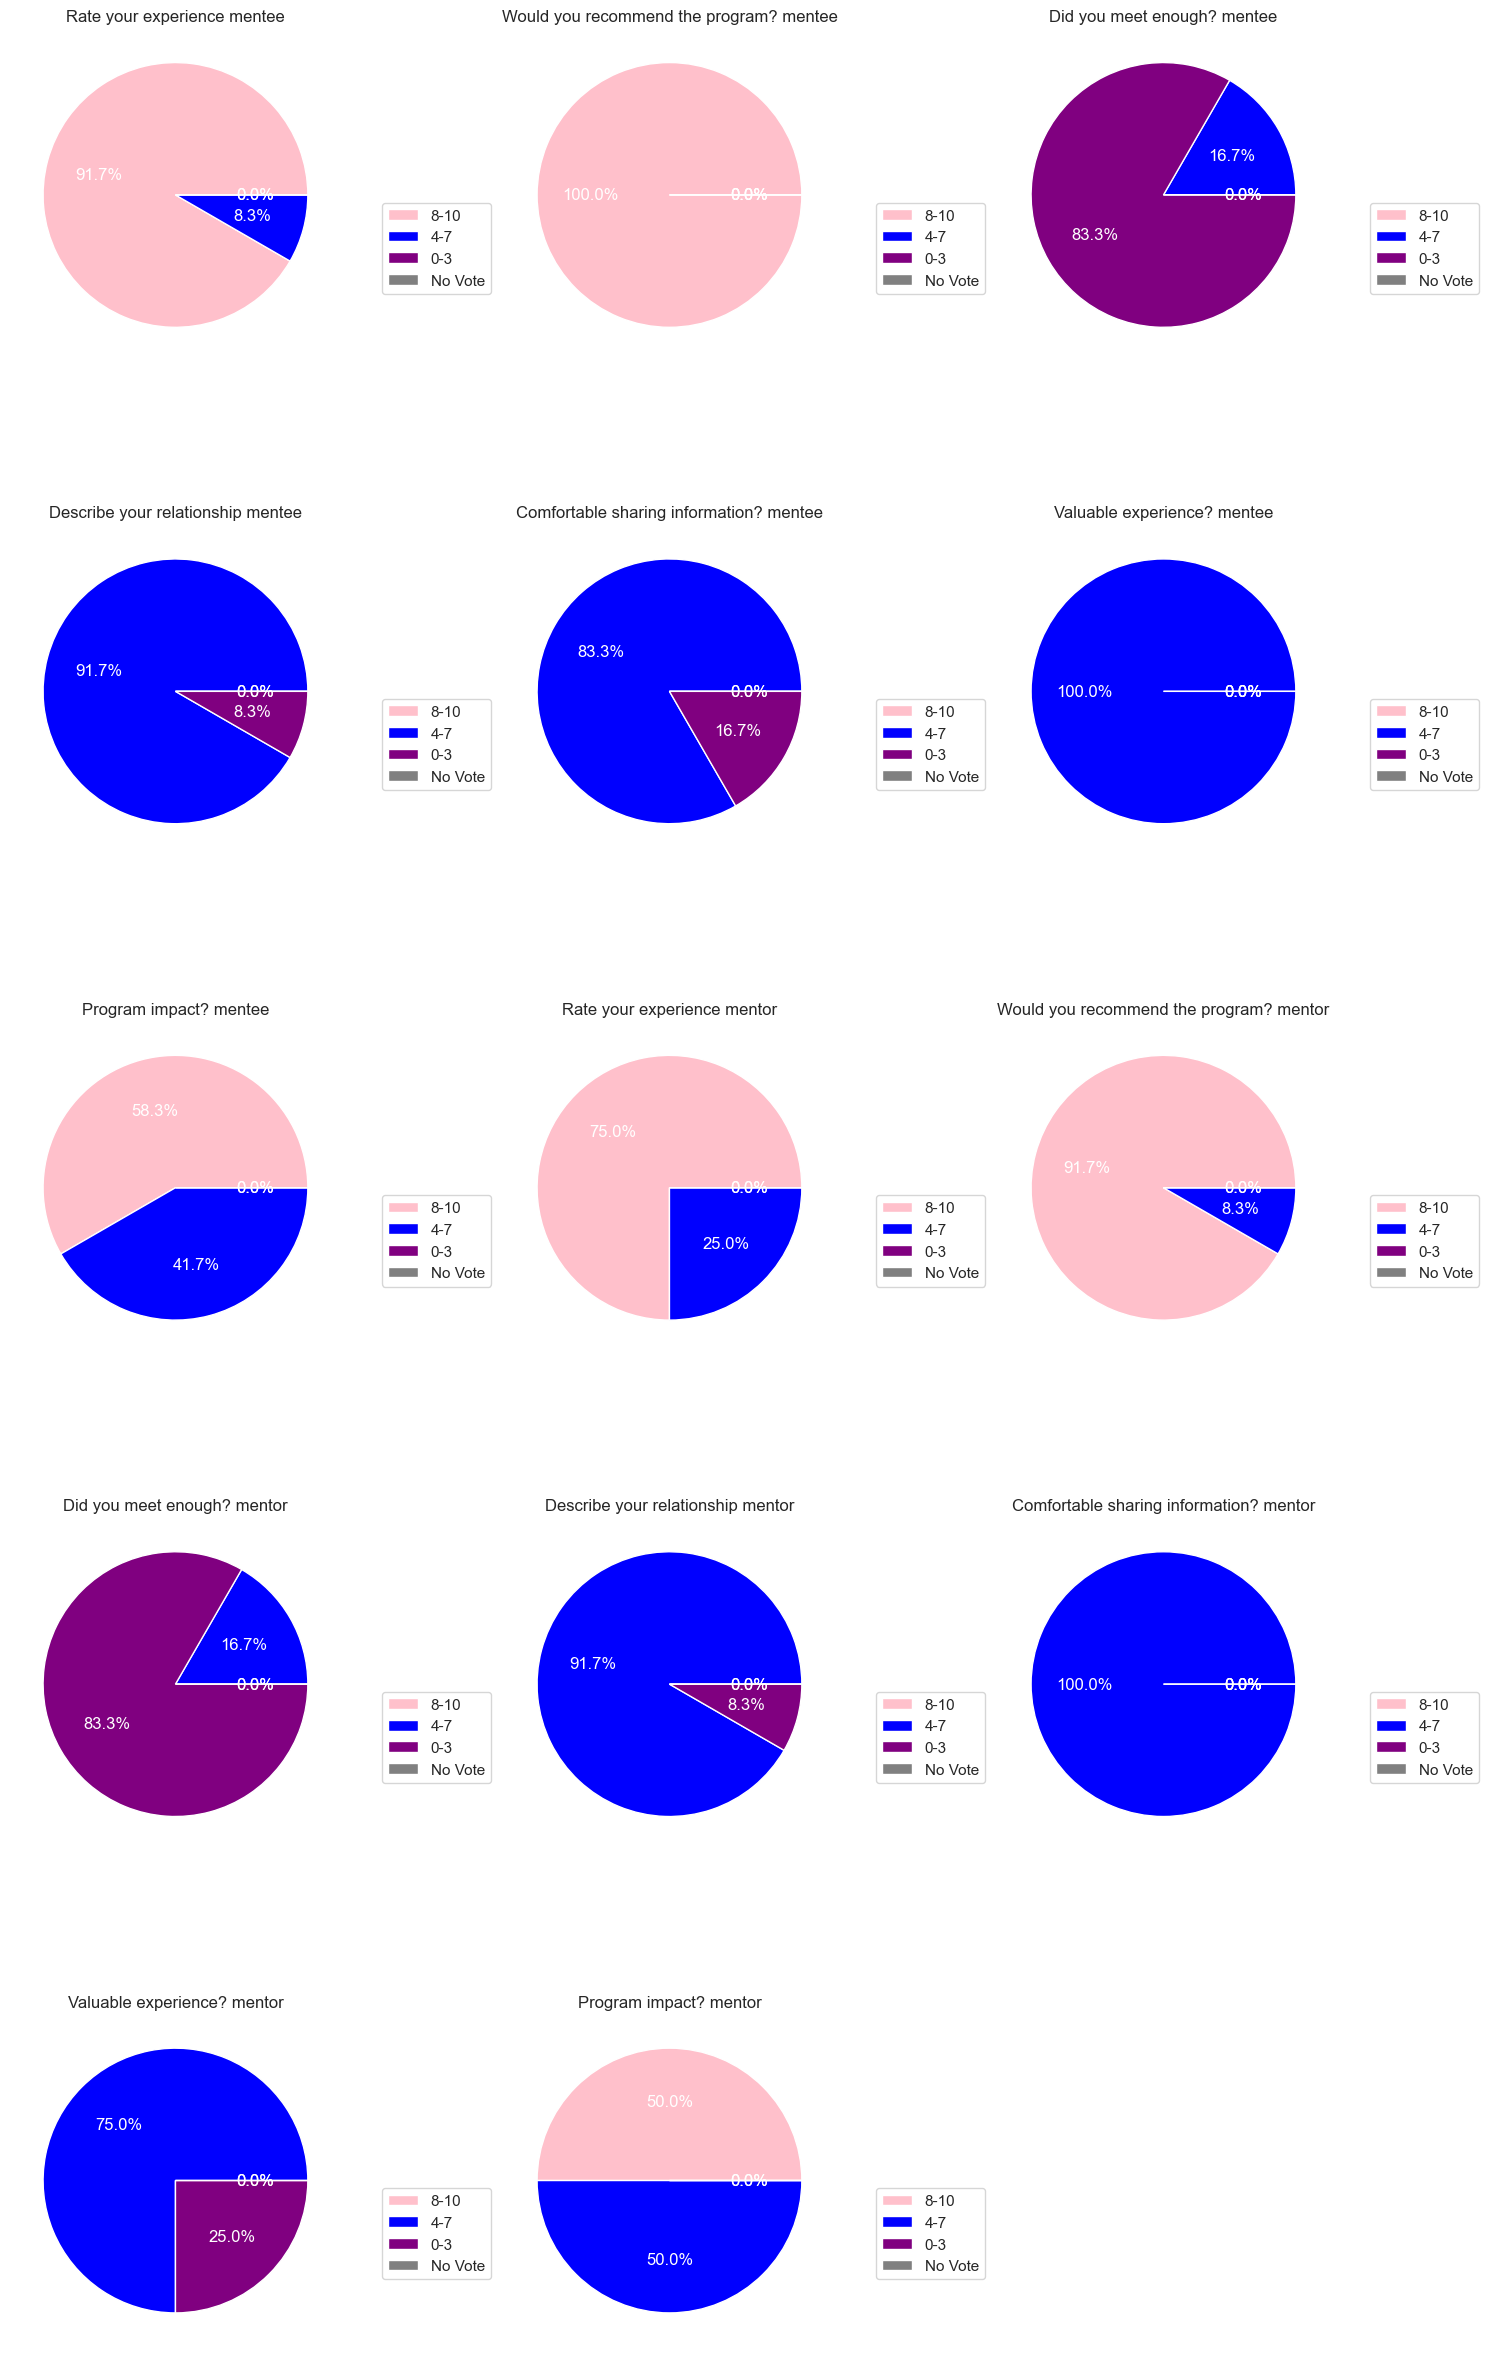

In [138]:
pie_plot(results['mentor_mentee_25_mid'])

## Trends over time
We currently have only 3 surveys, but hoping to add more points as more data comes in in the future. The purpose of the line plot is to see trends and changes over time. 

In [ ]:
def merge_mentor_mentee_with_nan(matches, mentees_data, mentors_data):
    merged = (matches.merge(mentees_data, left_on='Mentee Name', right_on='Your Name')
    .merge(mentors_data, left_on='Mentor Name', right_on='Your Name', suffixes=('_mentee', '_mentor')))
    
    merged.drop(columns=['Your Name_mentee', 'Your Name_mentor'], inplace=True)
    merged.fillna(-1, inplace=True)
    return merged

In [150]:
merged_df

,questions,mid_mentee_24,mid_mentor_24,eop_mentee_24,eop_mentor_24,mid_mentee_25,mid_mentor_25
0,Rate your experience,8.00,8.60,8.08,8.11,8.39,8.10
1,Would you recommend the program?,9.13,9.10,9.00,9.11,8.96,8.62
2,Did you meet enough?,3.13,2.95,3.08,2.83,3.00,2.83
3,Describe your relationship,4.27,4.20,4.17,4.11,4.00,4.00
4,Comfortable sharing information?,4.60,4.75,4.67,4.78,4.52,4.90
5,Valuable experience?,4.20,4.05,4.00,4.11,4.35,4.03
6,Program impact?,7.40,6.55,7.50,6.78,7.17,7.03


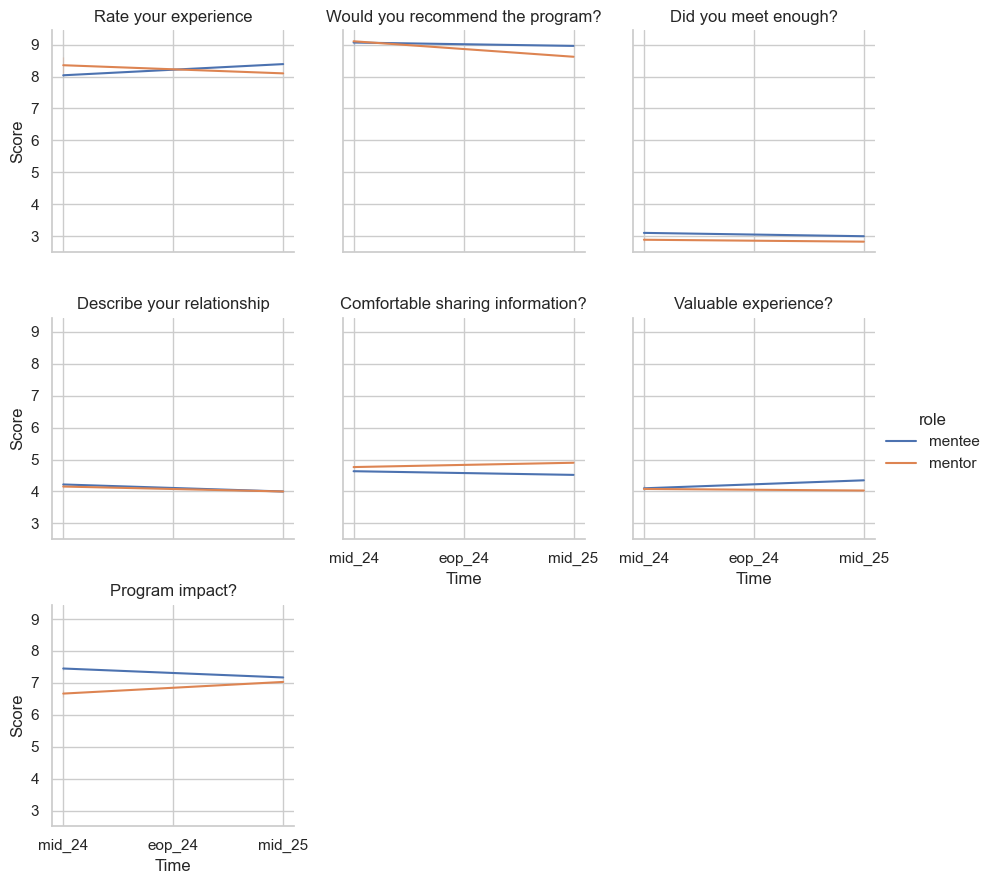

In [156]:
# progress, mentees- one line, mentors- another line
import warnings
def trends(df):
    warnings.filterwarnings("ignore", category=FutureWarning)
    df = pd.melt(df, id_vars= 'questions', value_vars = ['mid_mentee_25', 'mid_mentor_25', 'mid_mentee_24', 'mid_mentor_24', 'eop_mentee_24', 'eop_mentor_24'],
                var_name='group', value_name='score')
    df['role'] = df['group'].apply(lambda x: 'mentee' if 'mentee' in x else 'mentor')
    df['time'] = df['group'].apply(lambda x: 'end_24' if 'eop_24' in x else 'mid_24' if '24' in x else 'mid_25' if '25' in x else 'end_25')
    df.drop('group', axis =1, inplace=True)

    order = ['mid_24', 'eop_24', 'mid_25', 'end_25']
    df['time'] = pd.Categorical(df['time'], categories=order, ordered = True)
    g = sns.FacetGrid(df, col='questions', col_wrap=3)
    g.map_dataframe(sns.lineplot, x= 'time', y='score', hue='role')
    g.add_legend(title='role')
    g.set_titles(col_template='{col_name}')
    g.set_axis_labels('Time', 'Score')
    plt.show()
    
trends(merged_df)

Overall, there isn't a drastic improvement or decline from the results in 2024.
Mentors' experience declined while the mentees' experience grew. More mentors in 2024 would recommend the program compared to those in 2025.
The program's impact increases from last year for mentors, while it has slightly decreased for mentees.

## Response Participation

Pie charts show response distributions across scoring bands (0–3, 4–7, 8–10), including “No Vote” entries.

This gives us a sense of how engaged participants were, highlighting the need for better participation numbers for better conclusion-making.

In [160]:
def everyone(matches, mentees_data, mentors_data):
    return (matches[['Mentor Name', 'Mentee Name']]
        .merge(mentees_data, left_on='Mentee Name', right_on='Your Name', how='left')
        .merge(mentors_data, left_on='Mentor Name', right_on='Your Name', how='left', suffixes=('_mentee', '_mentor'))
        .drop(columns=['Your Name_mentee', 'Your Name_mentor'])
        .fillna(-1))

everyone_inputs = {'everyone_24_mid': (matches_24, mid_mentee_24, mid_mentor_24),
                    'everyone_24_eop': (matches_24, eop_mentee_24, eop_mentor_24),
                    'everyone_25_mid': (matches_25, mid_mentee_25, mid_mentor_25)}

everyone_results = {name: everyone(matches, mentees, mentors)
                    for name, (matches, mentees, mentors) in everyone_inputs.items()}

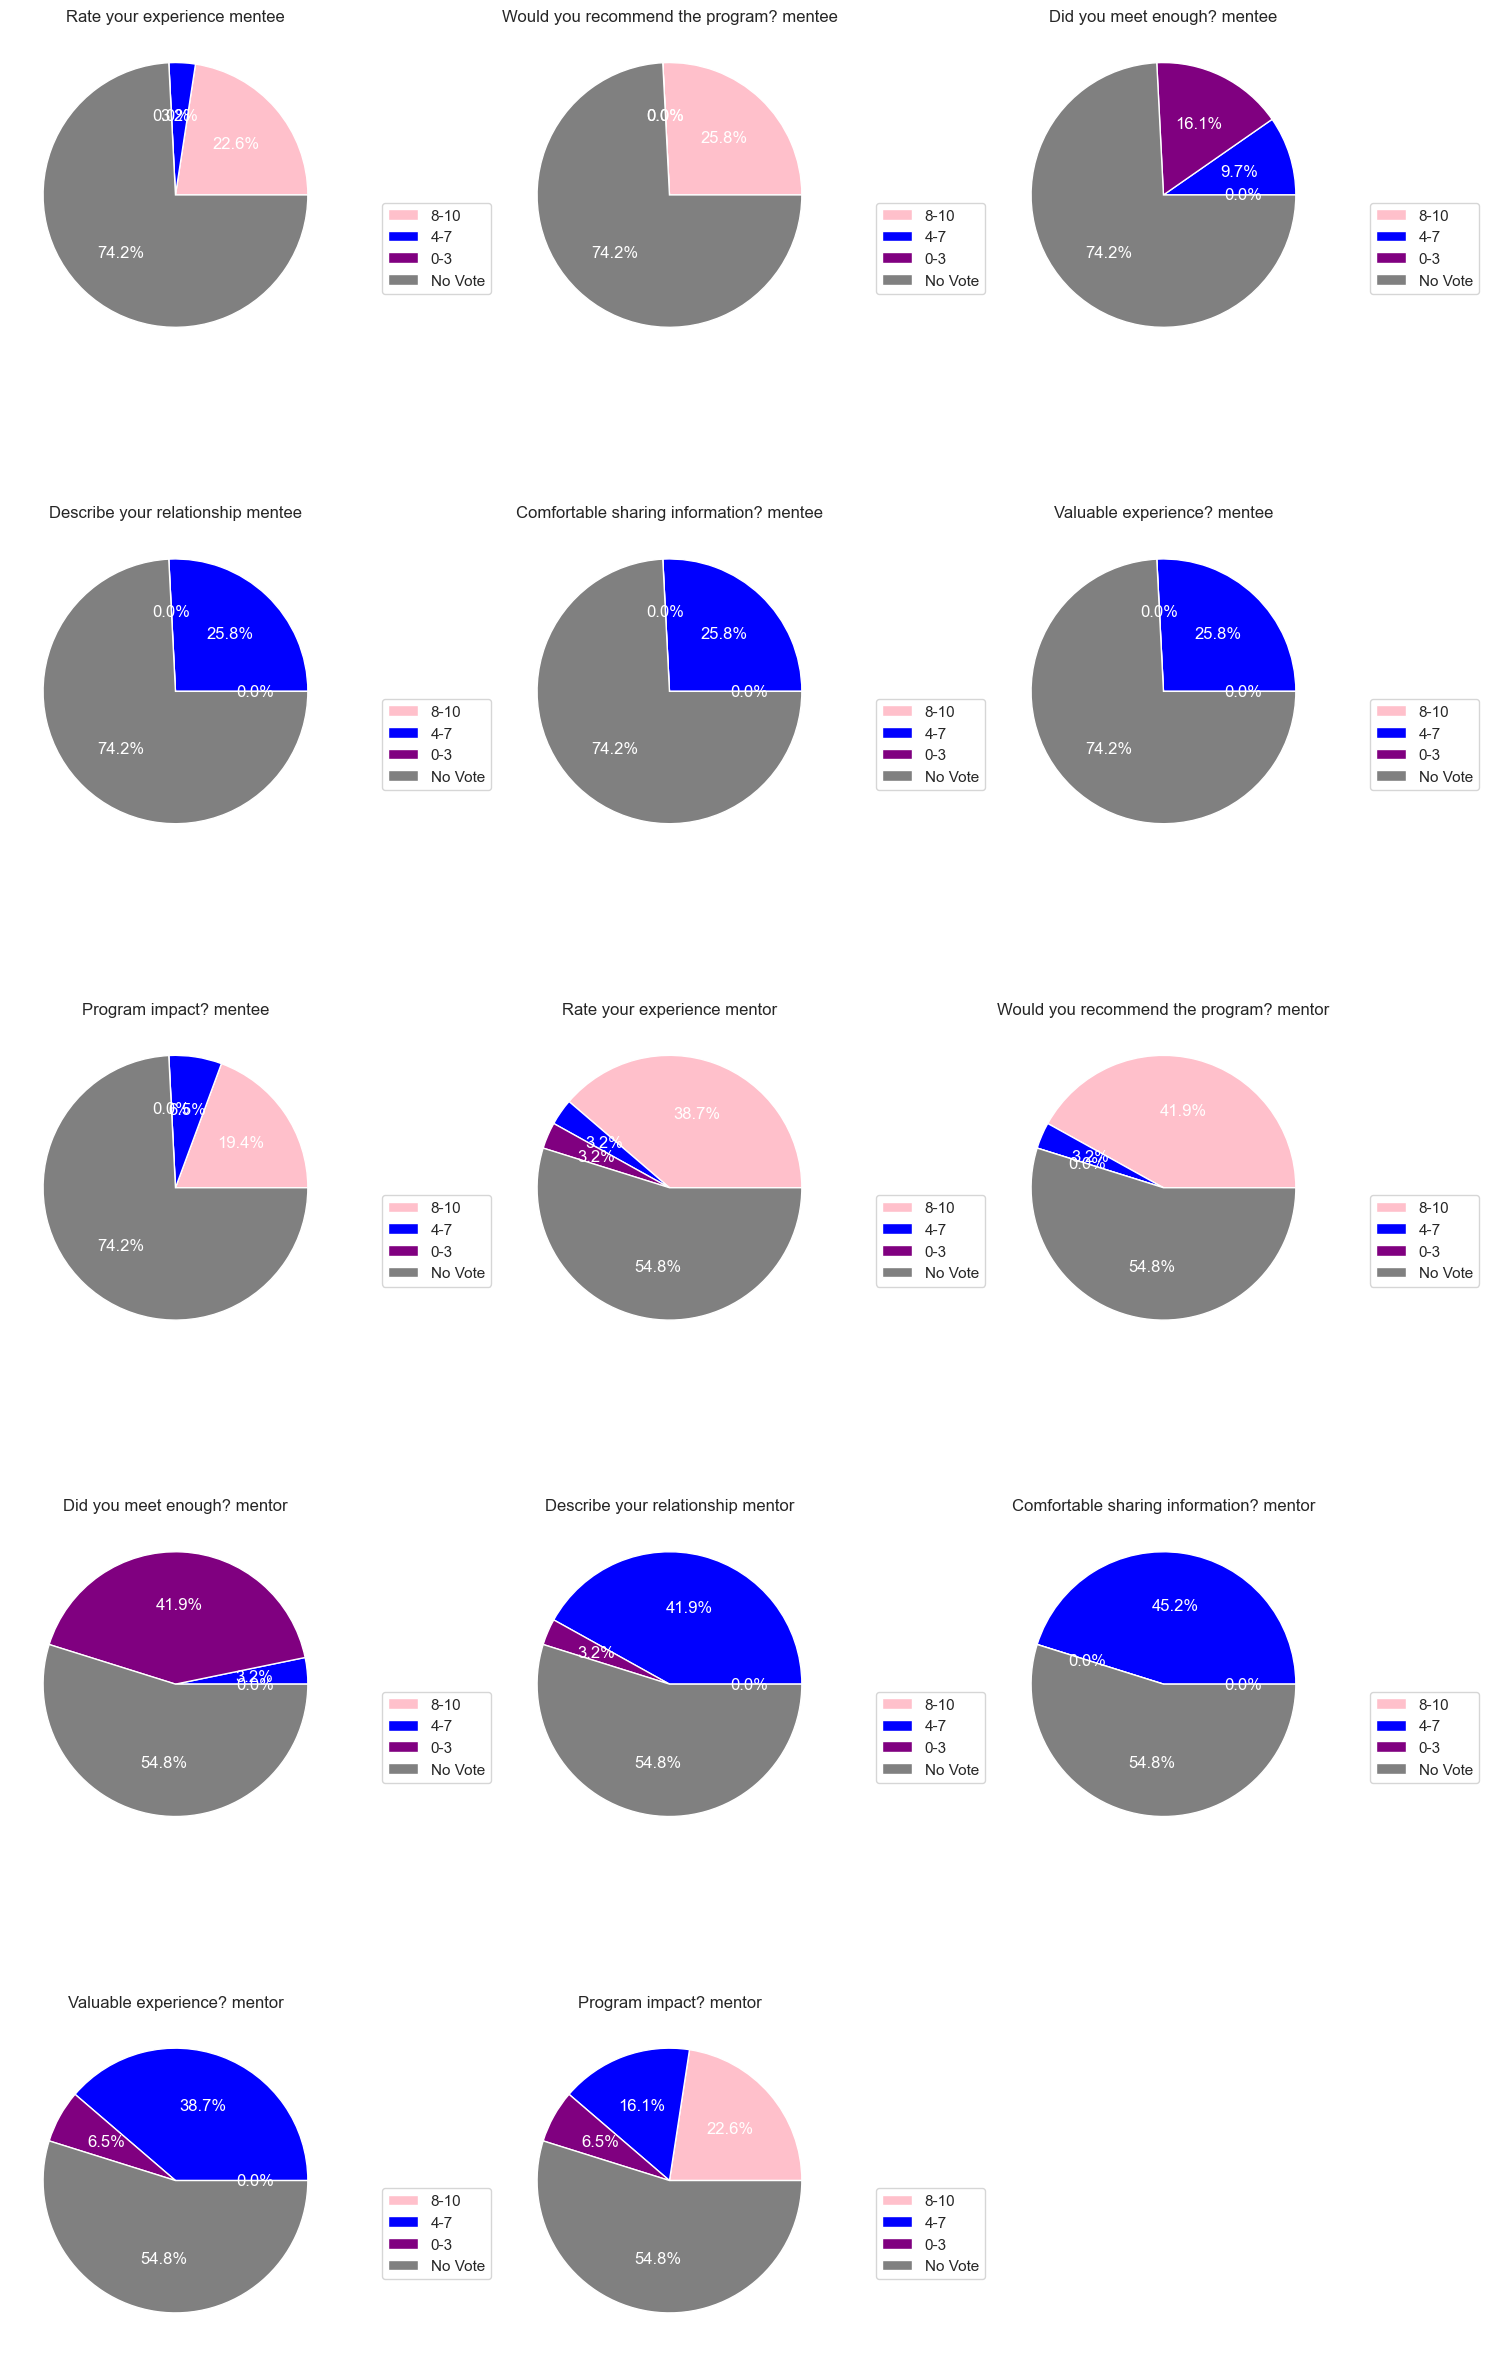

In [162]:
pie_plot(everyone_results['everyone_24_eop'])

### Midterm 2025

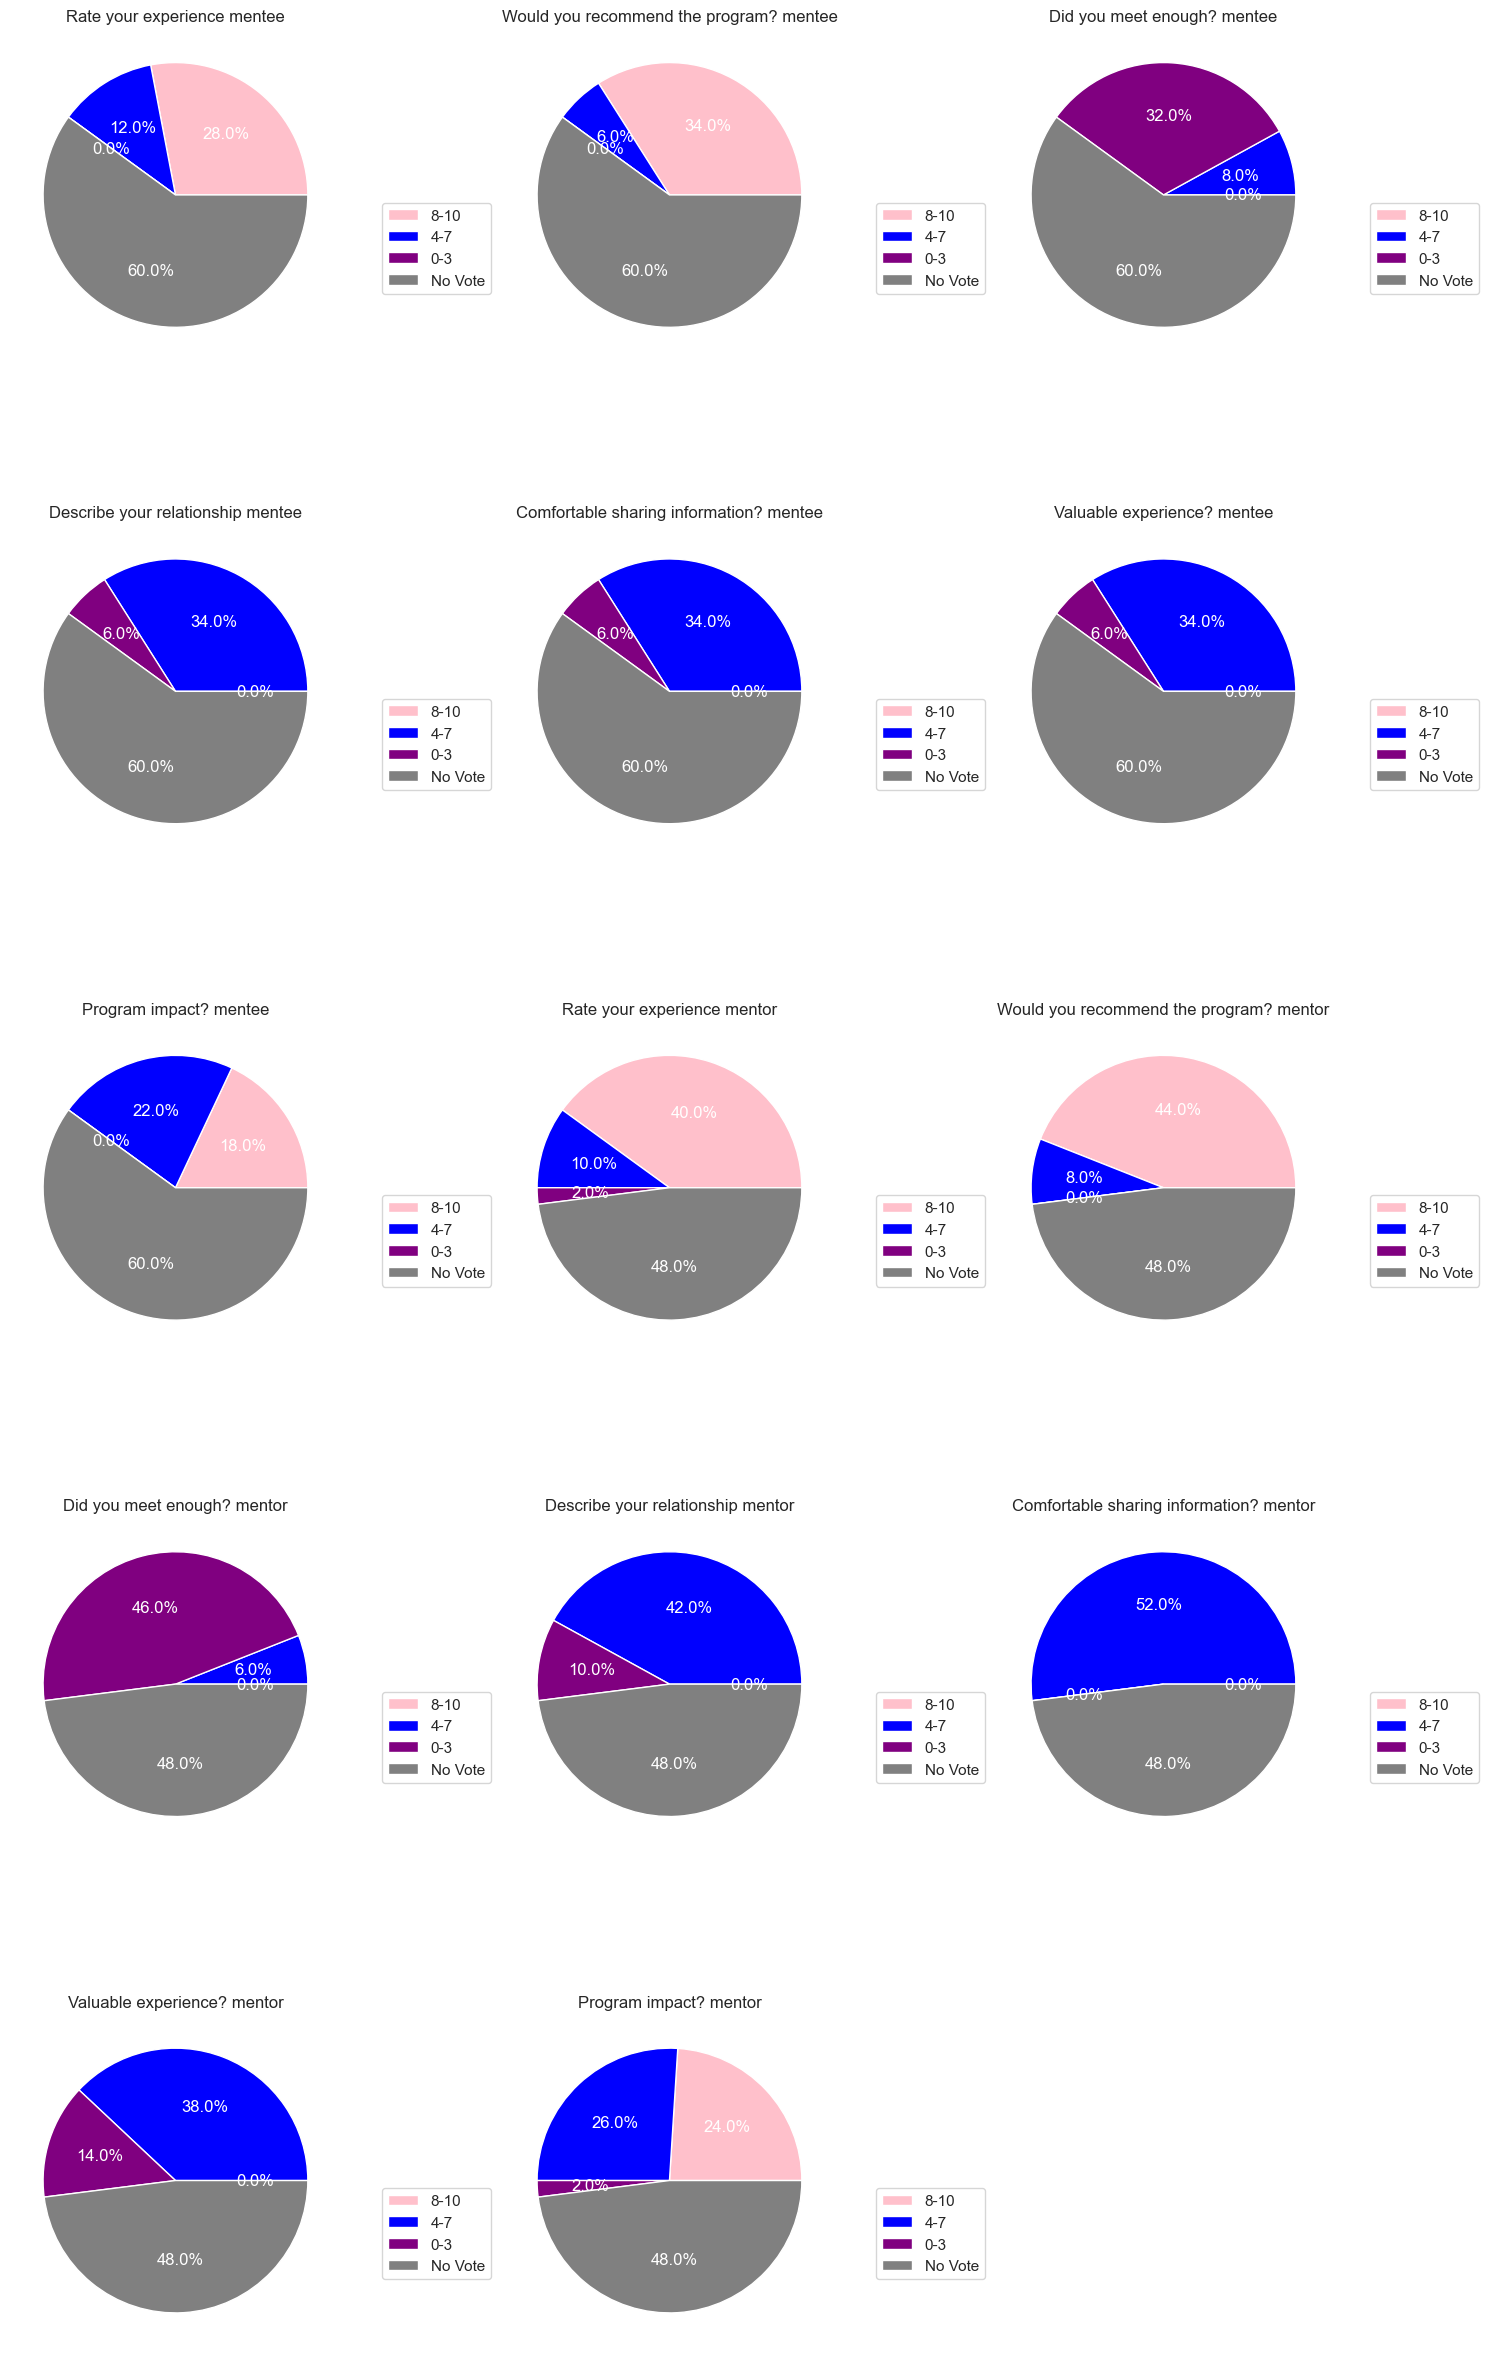

In [166]:
pie_plot(everyone_results['everyone_25_mid'])

# Conclusion 
Due to the large precentage of non voters, and the small number of responses, it is hard to make conclusions about the program as a whole. 
From the data we can conclude that most of the participants, mentors and mentees are satisfied from the program and its aspects. However, less participants ranked the impact of the program as high, which is an are we can dive deeper to try and understand the reasoning to.

# Recommendations
Encourage and mendate responses to the surveys, from both mentors and mentees.
Seek reasoning on how to increase the program's impact.